# Thesis Publication Figures

This notebook prepares publication-style figures for the multihole Mie pipeline and the Stage-1 MLP section.

Generated figures in this version:

- `images/fig_mie_preproc_background.png`
- `images/fig_mie_preproc_sobel.png`
- `images/fig_angular_occupancy.png`
- `images/fig_efficient_rotation.png`
- `images/fig_round1_median_selection.png`
- `images/fig_round1_loss.png`

Deferred/manual figures:

- `fig_gui_main_window` (manual)
- `fig_gui_point_selection` (manual)
- `fig_gui_calibration_overlay` (manual)
- `fig_round2_uncertainty_placeholder` (deferred)
- `fig_round3_refinement_placeholder` (deferred)


## Source Anchors

This notebook is anchored to the following dataset:

- cine: `F:\\LubeOil\\BC20241010_HZ_Nozzle5\\Cine\\T13\\5.cine`
- config: `F:\\LubeOil\\BC20241010_HZ_Nozzle5\\Cine\\T13\\config.json`

Pipeline references reused conceptually or directly:

- `main.py`
- `mie_multihole_pipeline.py`
- `OSCC_postprocessing/binary_ops/masking.py`
- `OSCC_postprocessing/analysis/cone_angle.py`
- `OSCC_postprocessing/analysis/multihole_utils.py`
- `OSCC_postprocessing/rotation/rotate_with_alignment_cpu.py`
- `MLP/median_penetration_MSE.ipynb`


## 00 Setup


In [106]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Circle


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR = IMAGE_DIR / "avi"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

CINE_PATH = Path(r"F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T1\4.cine")
CONFIG_PATH = Path(r"F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T1\config.json")
ROUND1_LOSS_CSV = PROJECT_ROOT / "MLP" / "stage1_median_penetration_20260306_172838" / "epoch_loss.csv"

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

COLORS = {
    "ink": "#16213e",
    "accent": "#0f766e",
    "warm": "#c2410c",
    "gold": "#b45309",
    "red": "#b91c1c",
    "blue": "#1d4ed8",
    "gray": "#6b7280",
}

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"IMAGE_DIR     = {IMAGE_DIR}")
print(f"VIDEO_DIR     = {VIDEO_DIR}")
print(f"CINE_PATH     = {CINE_PATH}")
print(f"CONFIG_PATH   = {CONFIG_PATH}")


PROJECT_ROOT = C:\Users\Jiang\Documents\Mie_Postprocessing_Py
IMAGE_DIR     = C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images
VIDEO_DIR     = C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\avi
CINE_PATH     = F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T1\4.cine
CONFIG_PATH   = F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T1\config.json


## 01 Dataset Anchor


In [107]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = json.load(f)

MIE_GEOMETRY = {
    "plumes": int(CONFIG["plumes"]),
    "offset": float(CONFIG["offset"]),
    "centre": (float(CONFIG["centre_x"]), float(CONFIG["centre_y"])),
    "inner_radius": float(CONFIG["inner_radius"]),
    "outer_radius": float(CONFIG["outer_radius"]),
}

print(json.dumps(MIE_GEOMETRY, indent=2))


{
  "plumes": 10,
  "offset": 36.11,
  "centre": [
    383.205,
    385.19
  ],
  "inner_radius": 13.0,
  "outer_radius": 412.0
}


## 02 Shared Helpers


In [108]:
OPTIONAL_IMPORTS: dict[str, str] = {}


def optional_import(name: str):
    try:
        module = __import__(name, fromlist=["*"])
        OPTIONAL_IMPORTS[name] = "OK"
        return module
    except Exception as exc:
        OPTIONAL_IMPORTS[name] = f"FAILED: {type(exc).__name__}: {exc}"
        return None


repo_masking = optional_import("OSCC_postprocessing.binary_ops.masking")
repo_cone = optional_import("OSCC_postprocessing.analysis.cone_angle")
repo_multi = optional_import("OSCC_postprocessing.analysis.multihole_utils")
repo_rotate = optional_import("OSCC_postprocessing.rotation.rotate_with_alignment_cpu")
repo_hysteresis = optional_import("OSCC_postprocessing.analysis.hysteresis")
repo_cine = optional_import("OSCC_postprocessing.cine.functions_videos")
repo_features = optional_import("OSCC_postprocessing.binary_ops.feature_extraction")
repo_playback = optional_import("OSCC_postprocessing.playback.video_playback")
repo_avi = optional_import("OSCC_postprocessing.io.async_avi_saver")
repo_main = optional_import("main")

OPTIONAL_IMPORTS


{'OSCC_postprocessing.binary_ops.masking': 'OK',
 'OSCC_postprocessing.analysis.cone_angle': 'OK',
 'OSCC_postprocessing.analysis.multihole_utils': 'OK',
 'OSCC_postprocessing.rotation.rotate_with_alignment_cpu': 'OK',
 'OSCC_postprocessing.analysis.hysteresis': 'OK',
 'OSCC_postprocessing.cine.functions_videos': 'OK',
 'OSCC_postprocessing.binary_ops.feature_extraction': 'OK',
 'OSCC_postprocessing.playback.video_playback': 'OK',
 'OSCC_postprocessing.io.async_avi_saver': 'OK',
 'main': "FAILED: ModuleNotFoundError: No module named 'main'"}

In [109]:
def add_panel_labels(axs, labels=None, x=0.01, y=0.99):
    labels = labels or list("abcdefghijklmnopqrstuvwxyz")
    for ax, label in zip(np.ravel(axs), labels):
        ax.text(
            x,
            y,
            f"({label})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
            fontweight="bold",
            color=COLORS["ink"],
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        )


def export_figure(fig, filename: str, show_inline: bool = True):
    out_path = IMAGE_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    if show_inline:
        display(fig)
    print(f"Saved {out_path}")
    return out_path


def to_numpy(arr):
    if hasattr(arr, "get"):
        arr = arr.get()
    elif hasattr(arr, "__cuda_array_interface__"):
        try:
            import cupy as cp
            arr = cp.asnumpy(arr)
        except Exception:
            pass
    return np.asarray(arr)


def robust_scale_local(arr, q_min=5.0, q_max=99.5, clip=True, eps=1e-8):
    arr = to_numpy(arr).astype(float, copy=False)
    lo = np.nanpercentile(arr, q_min)
    hi = np.nanpercentile(arr, q_max)
    scaled = (arr - lo) / max(hi - lo, eps)
    if clip:
        scaled = np.clip(scaled, 0.0, 1.0)
    return scaled


def angular_distance_deg(theta_deg, ref_deg):
    delta = (theta_deg - ref_deg + 180.0) % 360.0 - 180.0
    return delta


def generate_ring_mask_local(height, width, centre, inner_radius, outer_radius):
    yy, xx = np.indices((height, width))
    dx = xx - centre[0]
    dy = yy - centre[1]
    rr2 = dx * dx + dy * dy
    return (rr2 >= inner_radius ** 2) & (rr2 <= outer_radius ** 2)


def generate_plume_mask_local(width, height, angle_deg=None, x0=0.0, y0=None):
    if repo_masking is not None and hasattr(repo_masking, "generate_plume_mask"):
        return np.asarray(repo_masking.generate_plume_mask(width, height, angle_deg, x0=int(x0), y0=y0), dtype=bool)

    y0 = height / 2.0 if y0 is None else y0
    if angle_deg is None:
        y1 = 0.0
        y2 = float(height)
    else:
        half_angle = np.deg2rad(angle_deg / 2.0)
        y1 = -width * np.tan(half_angle) + height / 2.0
        y2 = width * np.tan(half_angle) + height / 2.0

    yy, xx = np.indices((height, width), dtype=float)
    x0 = float(x0)
    denom = max(width - x0, 1e-6)
    top_edge = y0 + (y1 - y0) * (xx - x0) / denom
    bottom_edge = y0 + (y2 - y0) * (xx - x0) / denom
    inside_triangle = (xx >= x0) & (yy >= np.minimum(top_edge, bottom_edge)) & (yy <= np.maximum(top_edge, bottom_edge))
    return inside_triangle


generate_ring_mask = generate_ring_mask_local
generate_plume_mask = generate_plume_mask_local


def angle_signal_density_local(video, x0, y0, n_bins=360, N_bins=None):
    if N_bins is not None:
        n_bins = N_bins
    arr = to_numpy(video)
    if arr.ndim == 2:
        arr = arr[None, ...]
    frames, height, width = arr.shape
    yy, xx = np.indices((height, width))
    theta = np.degrees(np.arctan2(yy - y0, xx - x0)) % 360.0
    edges = np.linspace(0.0, 360.0, n_bins + 1)
    inds = np.digitize(theta.ravel(), edges) - 1
    inds = np.clip(inds, 0, n_bins - 1)
    counts = np.bincount(inds, minlength=n_bins)
    signal = np.empty((frames, n_bins), dtype=float)
    flat = arr.reshape(frames, -1)
    for frame_idx in range(frames):
        signal[frame_idx] = np.bincount(inds, weights=flat[frame_idx], minlength=n_bins)
    density = signal / np.maximum(counts, 1)[None, :]
    centers = edges[:-1] + 0.5 * (edges[1] - edges[0])
    return centers, signal, density


angle_signal_density_auto = angle_signal_density_local


def estimate_offset_from_fft_local(signal, number_of_plumes):
    signal = to_numpy(signal).astype(float, copy=False)
    summed_signal = signal.sum(axis=0)
    fft_vals = np.fft.rfft(summed_signal)
    if number_of_plumes >= len(fft_vals):
        return 0.0
    phase = np.angle(fft_vals[number_of_plumes])
    offset = (-phase / number_of_plumes) * 180.0 / np.pi
    offset %= 360.0
    return min(offset, offset - 360.0, key=abs)


estimate_offset_from_fft = estimate_offset_from_fft_local


def fill_short_false_runs_local(mask, max_len=3):
    mask = to_numpy(mask).astype(bool, copy=True)
    n = mask.size
    if n == 0 or mask.all() or (~mask).all():
        return mask
    doubled = np.concatenate([mask, mask])
    idx = 0
    while idx < 2 * n:
        if doubled[idx]:
            idx += 1
            continue
        start = idx
        while idx < 2 * n and not doubled[idx]:
            idx += 1
        stop = idx
        run_len = stop - start
        left_true = doubled[start - 1] if start > 0 else doubled[-1]
        right_true = doubled[stop] if stop < 2 * n else doubled[0]
        if left_true and right_true and run_len <= max_len:
            doubled[start:stop] = True
    return doubled[:n]


fill_short_false_runs = fill_short_false_runs_local


def remove_short_true_runs(mask, min_len=5):
    mask = to_numpy(mask).astype(bool, copy=True)
    n = mask.size
    if n == 0:
        return mask
    idx = 0
    while idx < n:
        if not mask[idx]:
            idx += 1
            continue
        start = idx
        while idx < n and mask[idx]:
            idx += 1
        stop = idx
        if stop - start < min_len:
            mask[start:stop] = False
    return mask


def safe_log_subtracted_foreground(video, frames_before_soi=10, noise_floor_multiplier=2.5):
    video = to_numpy(video).astype(float, copy=False)
    frames_before_soi = max(1, min(frames_before_soi, len(video)))
    eps = 1e-9
    log_video = np.log(video + eps)
    log_background = np.median(log_video[:frames_before_soi], axis=0, keepdims=True)
    background = np.exp(log_background[0])
    dff = np.expm1(log_video - log_background)
    noise_mask = video > (background[None, ...] * noise_floor_multiplier)
    dff *= noise_mask
    baseline = np.median(dff[:frames_before_soi], axis=0, keepdims=True)
    dff -= baseline
    foreground = np.maximum(dff - 0.05, 0.0)
    return background, robust_scale_local(foreground, q_min=5.0, q_max=99.99)


def sobel_magnitude_video_local(video):
    video = np.asarray(video, dtype=float)
    grad_y = np.gradient(video, axis=1)
    grad_x = np.gradient(video, axis=2)
    return np.sqrt(grad_x ** 2 + grad_y ** 2)


def occupancy_mask_from_profile(profile, max_gap=3):
    profile = robust_scale_local(profile, q_min=2.0, q_max=99.8)
    positive = profile[profile > 0]
    if positive.size == 0:
        return np.zeros_like(profile, dtype=bool)
    threshold = np.clip(np.median(positive) + 0.25 * np.std(positive), 0.2, 0.75)
    mask = profile >= threshold
    return fill_short_false_runs(mask, max_len=max_gap)


def try_load_cine_fps(cine_path: Path):
    if repo_cine is None or not hasattr(repo_cine, "cine"):
        return None
    try:
        header = repo_cine.cine.read_header(cine_path)
    except Exception:
        return None
    setup = header.get("setup")
    for attr in ("FrameRate", "FrameRate16", "fPbRate"):
        value = getattr(setup, attr, None)
        if value is not None and float(value) > 0:
            return float(value)
    return None


def binarize_segments_like_main(segments):
    segments_np = np.asarray(to_numpy(segments), dtype=np.float32)
    if repo_main is not None and hasattr(repo_main, "triangle_binarize_gpu") and hasattr(repo_main, "robust_scale"):
        scaled = repo_main.robust_scale(segments_np, 5, 99.9)
        if hasattr(repo_main, "cp") and getattr(repo_main, "xp", None) is getattr(repo_main, "cp", None):
            scaled = repo_main.cp.asarray(scaled)
        bw = repo_main.triangle_binarize_gpu(scaled)
        return to_numpy(bw).astype(bool)
    scaled = robust_scale_local(segments_np, q_min=5.0, q_max=99.9)
    return scaled >= 0.5


def compute_penetration_cdf_like_main(segments, inner_radius, q=1.0 - 5e-3):
    segments_arr = np.asarray(to_numpy(segments), dtype=np.float32)

    def _postprocess_penetration(penetration):
        penetration = np.asarray(to_numpy(penetration), dtype=float)
        penetration_diff = np.diff(penetration, axis=1)
        x_loc, y_loc = np.where(penetration_diff < 0)
        for plume_idx, frame_idx in zip(x_loc, y_loc):
            penetration[plume_idx, frame_idx - 1 :] = np.nan

        valid_mask = ~np.isnan(penetration)
        for plume_idx in range(valid_mask.shape[0]):
            valid_mask[plume_idx] = remove_short_true_runs(valid_mask[plume_idx], min_len=5)
        return penetration * valid_mask

    def _fallback_penetration():
        heatmaps = segments_arr.sum(axis=2)  # (P, F, W)
        plume_count, frame_count, width = heatmaps.shape
        out = np.zeros((plume_count, frame_count), dtype=float)
        for plume_idx in range(plume_count):
            intensity = heatmaps[plume_idx].copy()
            baseline = np.median(intensity[:, :10], axis=1, keepdims=True)
            intensity -= baseline
            intensity = np.clip(intensity, 0.0, None)
            cdf = np.cumsum(intensity, axis=1)
            total = cdf[:, -1]
            valid = total > 1e-6
            if not np.any(valid):
                continue
            target = q * total[valid]
            idx = np.argmax(cdf[valid] >= target[:, None], axis=1).astype(float)
            out[plume_idx, valid] = np.maximum.accumulate(np.maximum(0.0, idx - float(inner_radius)))
        return out

    if repo_main is not None and hasattr(repo_main, "penetration_cdf_all_plumes"):
        try:
            segments_backend = segments_arr
            if hasattr(repo_main, "cp") and getattr(repo_main, "xp", None) is getattr(repo_main, "cp", None):
                segments_backend = repo_main.cp.asarray(segments_arr)
            penetration = repo_main.penetration_cdf_all_plumes(segments_backend, inner_radius, quantile=q)
            penetration = _postprocess_penetration(penetration)
            if np.any(np.isfinite(penetration)):
                return penetration
            print("compute_penetration_cdf_like_main: repo_main result was all-NaN, falling back to local CPU estimator.")
        except Exception as exc:
            print(f"compute_penetration_cdf_like_main: repo_main path failed ({type(exc).__name__}: {exc}); falling back to local CPU estimator.")

    return _fallback_penetration()


def extract_plume_metrics_like_main(segments_bw, penetration_cdf=None, umbrella_angle=180.0):
    frame_count = int(segments_bw.shape[1])
    metric_columns = {"frame_idx": np.arange(frame_count)}
    boundaries = []

    if penetration_cdf is not None:
        penetration_cdf = np.asarray(to_numpy(penetration_cdf), dtype=float)
        for plume_idx in range(penetration_cdf.shape[0]):
            metric_columns[f"penetration_cdf_plume_{plume_idx}"] = penetration_cdf[plume_idx]

    if repo_features is None or not hasattr(repo_features, "extract_single_plume_features"):
        return pd.DataFrame(metric_columns), boundaries

    opening_h = getattr(repo_main, "nozzle_opening_detection_height", 20) if repo_main is not None else 20
    opening_w = getattr(repo_main, "nozzle_opening_detection_width", 30) if repo_main is not None else 30
    penetration_pix = getattr(repo_main, "thres_penetration_num_pix", 5) if repo_main is not None else 5

    for plume_idx, segment_bw in enumerate(segments_bw):
        metrics = repo_features.extract_single_plume_features(
            segment_bw,
            nozzle_opening_detection_height=opening_h,
            nozzle_opening_detection_width=opening_w,
            umbrella_angle=umbrella_angle,
            thres_penetration_num_pix=penetration_pix,
        )
        boundaries.append(metrics.get("boundary"))
        for key, values in metrics.items():
            if key == "boundary":
                continue
            if np.isscalar(values):
                arr = np.full(frame_count, values)
            else:
                arr = to_numpy(values)
            metric_columns[f"{key}_plume_{plume_idx}"] = arr
    return pd.DataFrame(metric_columns), boundaries


def save_bundle_videos(bundle, prefix="mie_bundle", fps=None, codec="XVID"):
    if repo_avi is None or not hasattr(repo_avi, "AsyncAVISaver"):
        raise RuntimeError("AsyncAVISaver is unavailable in this kernel.")
    fps = int(round(bundle.get("fps") or fps or 30))
    saver = repo_avi.AsyncAVISaver(max_workers=2, default_codec=codec)
    saver.save(VIDEO_DIR / f"{prefix}_raw.avi", to_numpy(bundle["video"]), fps=fps)
    saver.save(VIDEO_DIR / f"{prefix}_foreground.avi", to_numpy(bundle["foreground"]), fps=fps)
    saver.save(VIDEO_DIR / f"{prefix}_highpass.avi", to_numpy(bundle["highpass"]), fps=fps)
    for plume_idx, segment in enumerate(to_numpy(bundle["segments"])):
        saver.save(VIDEO_DIR / f"{prefix}_segment_plume_{plume_idx}.avi", segment, fps=fps)
    for plume_idx, segment_bw in enumerate(to_numpy(bundle["segments_bw"])):
        saver.save(VIDEO_DIR / f"{prefix}_segment_bw_plume_{plume_idx}.avi", segment_bw.astype(np.uint8), fps=fps)
    saver.wait()
    saver.shutdown(wait=True)
    return VIDEO_DIR


def play_bundle_videos(bundle, *, play_processed=False, play_segments=False, gain=1.0, intv=17):
    if repo_playback is None:
        raise RuntimeError("Playback helpers are unavailable in this kernel.")
    if play_processed:
        repo_playback.play_video_cv2(to_numpy(bundle["highpass"]), gain=gain, intv=intv)
    if play_segments:
        segment_list = np.swapaxes(to_numpy(bundle["segments"]), 2, 3).tolist()
        repo_playback.play_videos_side_by_side(segment_list, gain=gain, intv=intv)


In [110]:
def synthetic_frame_shape(centre, outer_radius, margin=56):
    max_extent = int(np.ceil(max(centre[0], centre[1], outer_radius) * 2 + margin))
    return max_extent, max_extent


def make_synthetic_mie_video(config, n_frames=80, seed=7):
    rng = np.random.default_rng(seed)
    centre = config["centre"]
    inner_radius = config["inner_radius"]
    outer_radius = config["outer_radius"]
    plumes = config["plumes"]
    offset = config["offset"]
    height, width = synthetic_frame_shape(centre, outer_radius)
    yy, xx = np.indices((height, width), dtype=float)
    dx = xx - centre[0]
    dy = yy - centre[1]
    rr = np.sqrt(dx * dx + dy * dy)
    theta = np.degrees(np.arctan2(dy, dx)) % 360.0
    radial_background = 0.10 + 0.10 * (rr / max(outer_radius, 1.0))
    illumination = 0.08 * (xx / max(width - 1, 1)) + 0.04 * (yy / max(height - 1, 1))
    ring_texture = 0.03 * np.cos((rr - inner_radius) / max(outer_radius, 1.0) * np.pi * 4)
    base = radial_background + illumination + ring_texture
    angles = np.linspace(0.0, 360.0, plumes, endpoint=False) - offset
    sector_width = 0.48 * (360.0 / plumes)
    frames = []
    for frame_idx in range(n_frames):
        frame = base.copy()
        progress = np.clip((frame_idx - 2) / max(n_frames - 6, 1), 0.0, 1.0)
        for plume_idx, angle in enumerate(angles):
            plume_phase = 0.25 * plume_idx
            front = inner_radius + 18.0 + progress * (outer_radius - inner_radius - 28.0) * (0.82 + 0.08 * np.sin(plume_phase))
            softness = 8.0 + 1.2 * plume_idx / max(plumes - 1, 1)
            radial_gate = 1.0 / (1.0 + np.exp((rr - front) / softness))
            radial_gate *= rr >= inner_radius
            angle_gate = np.exp(-(angular_distance_deg(theta, angle) / sector_width) ** 2)
            filament = 0.05 * np.sin(0.05 * rr + 0.4 * frame_idx + plume_idx)
            plume = (0.22 + 0.04 * np.cos(0.35 * frame_idx + plume_idx)) * angle_gate * radial_gate
            plume *= 1.0 + filament
            frame += plume
        frame += 0.01 * rng.standard_normal(frame.shape)
        frame = np.clip(frame, 0.0, None)
        frames.append(frame)
    video = np.stack(frames, axis=0)
    video = robust_scale_local(video, q_min=1.0, q_max=99.8)
    return video.astype(np.float32)


def try_load_cine_video_sample(cine_path: Path, frame_limit=80):
    if repo_cine is None or not hasattr(repo_cine, "load_cine_video"):
        return None, "cine loader unavailable in current kernel"
    try:
        video = repo_cine.load_cine_video(cine_path, frame_limit=frame_limit)
        video = to_numpy(video).astype(np.float32, copy=False)
        if video.size == 0:
            return None, "cine loader returned an empty array"
        vmax = float(np.nanmax(video))
        if vmax > 0:
            video = video / vmax
        return video, f"real cine sample loaded ({video.shape[0]} frames)"
    except Exception as exc:
        return None, f"cine loading failed: {type(exc).__name__}: {exc}"


def build_mie_bundle(config, cine_path, frame_limit=80, frames_before_soi=10, noise_floor_multiplier=2.5, bins=720, seed=7):
    video_real, note = try_load_cine_video_sample(cine_path, frame_limit=frame_limit)
    if video_real is None:
        video = make_synthetic_mie_video(config, n_frames=frame_limit, seed=seed)
        source = "synthetic"
        source_note = f"Synthetic fallback in use. Reason: {note}."
        fps = float(config.get("fps", 34_000.0))
    else:
        video = video_real
        source = "real"
        source_note = f"Real cine reference in use. {note}."
        fps = float(try_load_cine_fps(cine_path) or config.get("fps", 34_000.0))

    height, width = video.shape[1:3]
    ring_mask = generate_ring_mask(height, width, config["centre"], config["inner_radius"], config["outer_radius"])
    background, foreground = safe_log_subtracted_foreground(
        video,
        frames_before_soi=frames_before_soi,
        noise_floor_multiplier=noise_floor_multiplier,
    )
    foreground = foreground * ring_mask[None, :, :]
    sobel_mag = sobel_magnitude_video_local(foreground)
    highpass = robust_scale_local(sobel_mag, q_min=5.0, q_max=99.95) * ring_mask[None, :, :]
    rep_idx = int(np.argmax(highpass.sum(axis=(1, 2))))

    angle_bins, angle_signal, _ = angle_signal_density_auto(
        foreground,
        config["centre"][0],
        config["centre"][1],
        N_bins=bins,
    )
    angle_signal = to_numpy(angle_signal).astype(float, copy=False)
    summed_profile = angle_signal.sum(axis=0)
    fft_offset = float(estimate_offset_from_fft(angle_signal, config["plumes"]))
    occupancy_mask = occupancy_mask_from_profile(summed_profile, max_gap=3)
    plume_angles = np.linspace(0.0, 360.0, config["plumes"], endpoint=False) - fft_offset

    out_shape = (int(config["outer_radius"] // 2), int(config["outer_radius"]))
    plume_mask = generate_plume_mask(out_shape[1], out_shape[0], 360.0 / config["plumes"], int(config["inner_radius"]))
    segments = []
    mapx = None
    mapy = None
    reference_angle = float(plume_angles[0])

    for plume_idx, angle in enumerate(plume_angles):
        if repo_rotate is not None and hasattr(repo_rotate, "rotate_video_nozzle_at_0_half_numpy"):
            rotated, mapx_i, mapy_i = repo_rotate.rotate_video_nozzle_at_0_half_numpy(
                np.asarray(highpass, dtype=np.float32),
                config["centre"],
                float(angle),
                interpolation="bilinear",
                out_shape=out_shape,
                border_mode="constant",
                cval=0.0,
                stack=True,
                plot_maps=False,
            )
            rotated = to_numpy(rotated).astype(np.float32, copy=False)
            if plume_idx == 0:
                mapx = to_numpy(mapx_i).astype(float, copy=False)
                mapy = to_numpy(mapy_i).astype(float, copy=False)
        else:
            out_h, out_w = out_shape
            xs = np.linspace(config["centre"][0], min(width - 1, config["centre"][0] + out_w), out_w)
            ys = np.linspace(max(0, config["centre"][1] - out_h / 2.0), min(height - 1, config["centre"][1] + out_h / 2.0), out_h)
            mapx_local, mapy_local = np.meshgrid(xs, ys)
            xi = np.clip(np.rint(mapx_local).astype(int), 0, width - 1)
            yi = np.clip(np.rint(mapy_local).astype(int), 0, height - 1)
            rotated = highpass[:, yi, xi]
            if plume_idx == 0:
                mapx = mapx_local
                mapy = mapy_local
        rotated *= plume_mask[None, :, :]
        segments.append(rotated)

    segments = np.stack(segments, axis=0)
    penetration_cdf = compute_penetration_cdf_like_main(segments, config["inner_radius"])
    segments_bw = binarize_segments_like_main(segments)
    metrics_df, boundaries = extract_plume_metrics_like_main(
        segments_bw,
        penetration_cdf=penetration_cdf,
        umbrella_angle=float(config.get("umbrella_angle_deg", 180.0)),
    )

    return {
        "source": source,
        "source_note": source_note,
        "fps": fps,
        "video": video,
        "ring_mask": ring_mask,
        "background": background,
        "foreground": foreground,
        "sobel_mag": sobel_mag,
        "highpass": highpass,
        "rep_idx": rep_idx,
        "angle_bins": np.asarray(angle_bins, dtype=float),
        "angle_signal": angle_signal,
        "summed_profile": summed_profile,
        "fft_offset": fft_offset,
        "occupancy_mask": occupancy_mask,
        "plume_angles": plume_angles,
        "mapx": mapx,
        "mapy": mapy,
        "rotated_strip": to_numpy(segments[0, rep_idx]).astype(float, copy=False),
        "plume_mask": to_numpy(plume_mask).astype(bool, copy=False),
        "reference_angle": reference_angle,
        "segments": segments,
        "segments_bw": segments_bw,
        "metrics_df": metrics_df,
        "boundaries": boundaries,
    }


def draw_geometry_overlay(ax, config, color=COLORS["warm"]):
    center = config["centre"]
    inner = Circle(center, radius=config["inner_radius"], fill=False, linewidth=1.2, edgecolor=color, alpha=0.9)
    outer = Circle(center, radius=config["outer_radius"], fill=False, linewidth=1.4, edgecolor=color, alpha=0.9)
    ax.add_patch(inner)
    ax.add_patch(outer)
    ax.plot(center[0], center[1], marker="+", color=COLORS["red"], markersize=8, mew=1.4)


In [111]:
MIE_BASE_PARAMS = {
    "frame_limit": 80,
    "frames_before_soi": 10,
    "noise_floor_multiplier": 2.5,
    "bins": 720,
    "seed": 7,
}

mie_bundle = build_mie_bundle(MIE_GEOMETRY, CINE_PATH, **MIE_BASE_PARAMS)
print(mie_bundle["source_note"])
print(f"Representative frame index: {mie_bundle['rep_idx']}")
print(f"Bundle FPS: {mie_bundle['fps']:.0f}")
print(f"Segments shape: {mie_bundle['segments'].shape}")
print(f"Metrics columns: {len(mie_bundle['metrics_df'].columns)}")


Video Info - Width: 768, Height: 768, Frames: 80
Real cine reference in use. real cine sample loaded (80 frames).
Representative frame index: 26
Bundle FPS: 34000
Segments shape: (10, 80, 206, 412)
Metrics columns: 151


## 03 Mie Figures


### fig_mie_preproc_background_placeholder


In [112]:
FIG_BG_PARAMS = {
    "filename": "fig_mie_preproc_background.png",
    "frame_idx": mie_bundle["rep_idx"],
}
FIG_BG_PARAMS


{'filename': 'fig_mie_preproc_background.png', 'frame_idx': 26}

In [113]:
fig_bg_data = {
    "raw": mie_bundle["video"][FIG_BG_PARAMS["frame_idx"]],
    "background": mie_bundle["background"],
    "foreground": mie_bundle["foreground"][FIG_BG_PARAMS["frame_idx"]],
    "source_note": mie_bundle["source_note"],
}


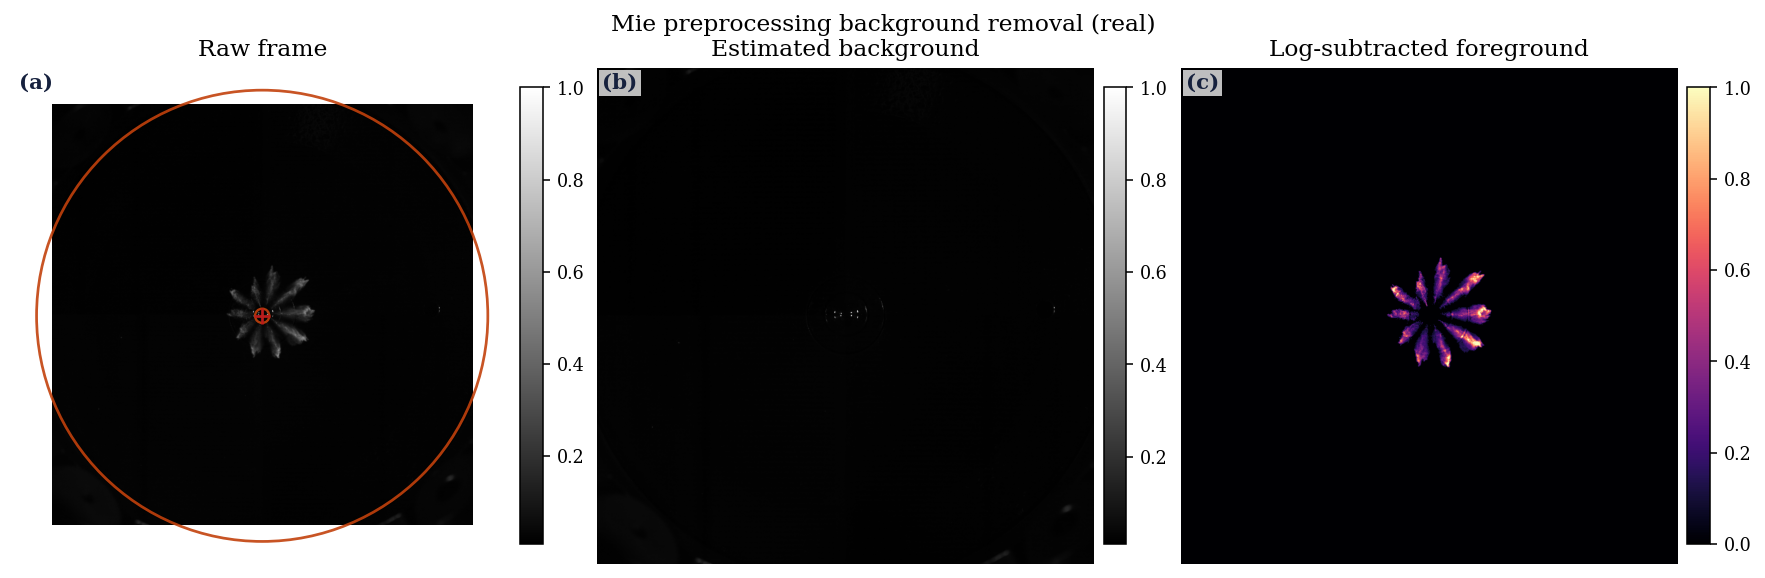

In [114]:
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.0), constrained_layout=True)
im0 = axs[0].imshow(fig_bg_data["raw"], cmap="gray")
axs[0].set_title("Raw frame")
draw_geometry_overlay(axs[0], MIE_GEOMETRY)
axs[0].set_axis_off()
im1 = axs[1].imshow(fig_bg_data["background"], cmap="gray")
axs[1].set_title("Estimated background")
axs[1].set_axis_off()
im2 = axs[2].imshow(fig_bg_data["foreground"], cmap="magma")
axs[2].set_title("Log-subtracted foreground")
axs[2].set_axis_off()
for ax, im in zip(axs, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle(f"Mie preprocessing background removal ({mie_bundle['source']})", y=1.03)
add_panel_labels(axs, labels=["a", "b", "c"])
plt.show()


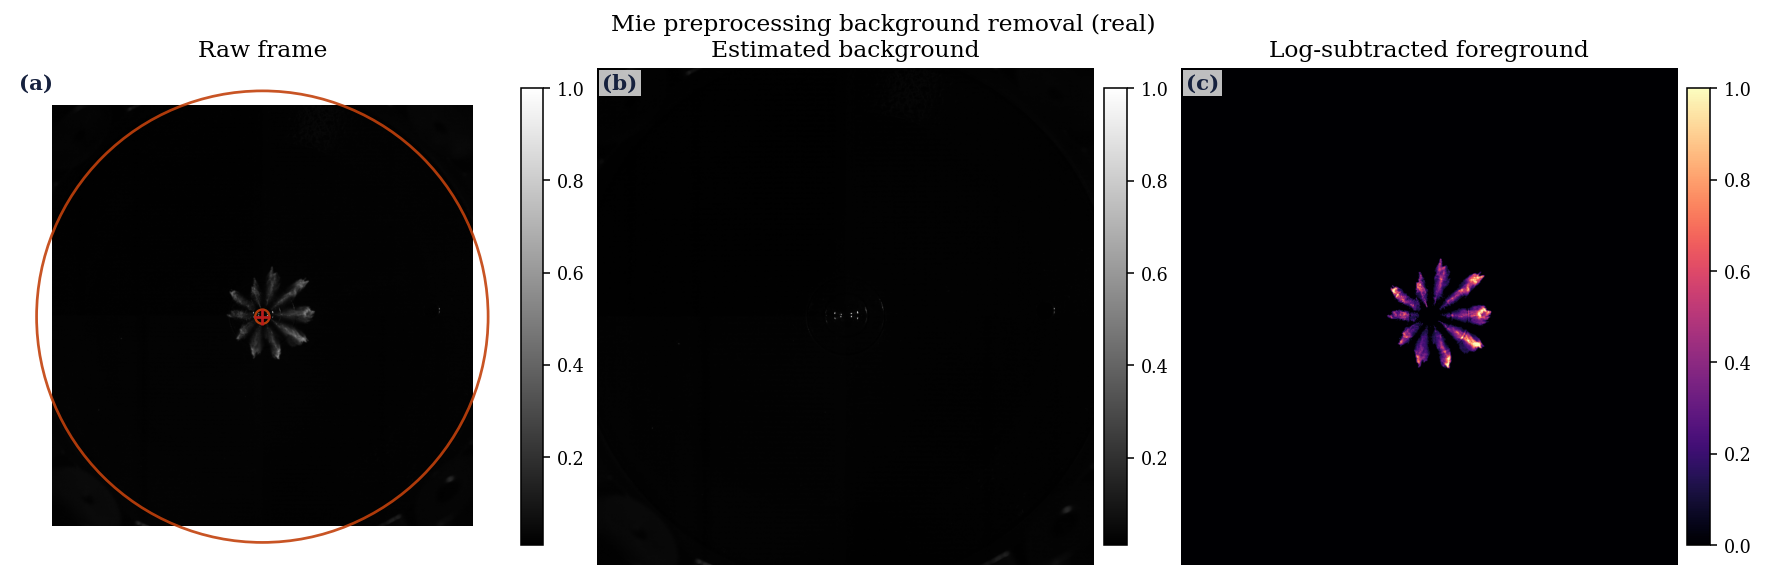

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_background.png


In [115]:
export_figure(fig, FIG_BG_PARAMS["filename"])
plt.close(fig)


### fig_mie_preproc_sobel_placeholder


In [116]:
FIG_SOBEL_PARAMS = {
    "filename": "fig_mie_preproc_sobel.png",
    "frame_idx": mie_bundle["rep_idx"],
}
FIG_SOBEL_PARAMS


{'filename': 'fig_mie_preproc_sobel.png', 'frame_idx': 26}

In [117]:
fig_sobel_data = {
    "foreground": mie_bundle["foreground"][FIG_SOBEL_PARAMS["frame_idx"]],
    "sobel": mie_bundle["sobel_mag"][FIG_SOBEL_PARAMS["frame_idx"]],
    "highpass": mie_bundle["highpass"][FIG_SOBEL_PARAMS["frame_idx"]],
}


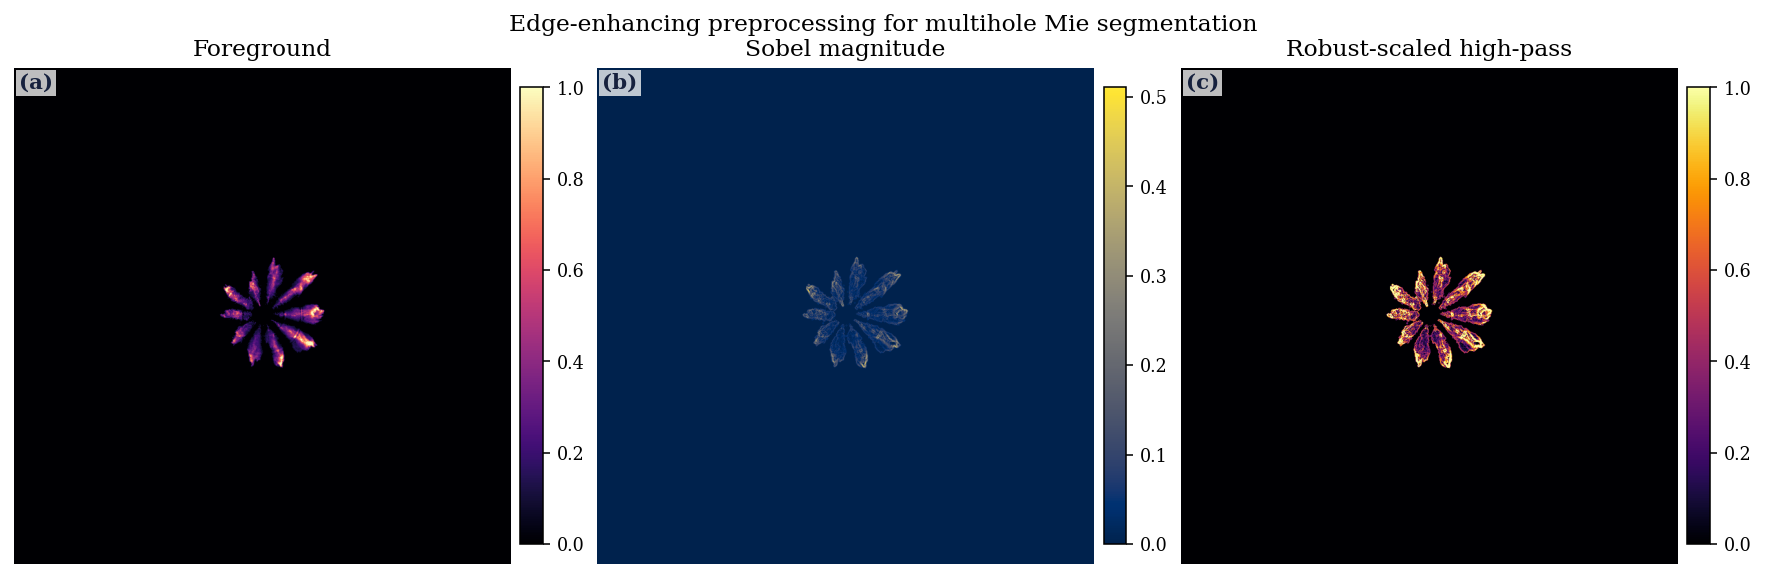

In [118]:
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.0), constrained_layout=True)
im0 = axs[0].imshow(fig_sobel_data["foreground"], cmap="magma")
axs[0].set_title("Foreground")
axs[0].set_axis_off()
im1 = axs[1].imshow(fig_sobel_data["sobel"], cmap="cividis")
axs[1].set_title("Sobel magnitude")
axs[1].set_axis_off()
im2 = axs[2].imshow(fig_sobel_data["highpass"], cmap="inferno")
axs[2].set_title("Robust-scaled high-pass")
axs[2].set_axis_off()
for ax, im in zip(axs, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle("Edge-enhancing preprocessing for multihole Mie segmentation", y=1.03)
add_panel_labels(axs, labels=["a", "b", "c"])
plt.show()


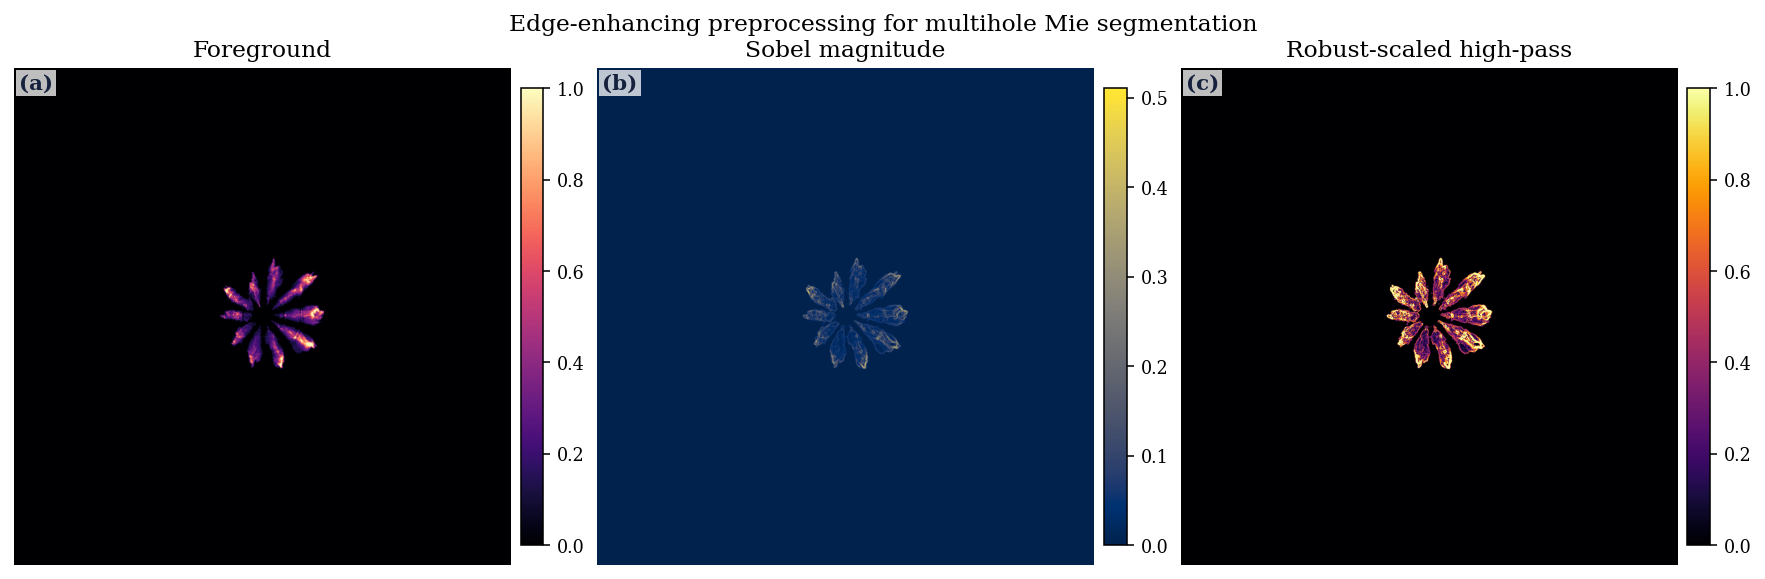

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_sobel.png


In [119]:
export_figure(fig, FIG_SOBEL_PARAMS["filename"])
plt.close(fig)


### fig_angular_occupancy_placeholder


In [120]:
FIG_ANGULAR_PARAMS = {
    "filename": "fig_angular_occupancy.png",
    "max_harmonic": 40,
}
FIG_ANGULAR_PARAMS


{'filename': 'fig_angular_occupancy.png', 'max_harmonic': 40}

In [121]:
fft_vals = np.fft.rfft(mie_bundle["summed_profile"])
fft_amp = np.abs(fft_vals)
harmonics = np.arange(len(fft_amp))
fig_angular_data = {
    "profiles": mie_bundle["angle_signal"],
    "bins": mie_bundle["angle_bins"],
    "summed_profile": mie_bundle["summed_profile"],
    "fft_amp": fft_amp,
    "harmonics": harmonics,
    "offset": mie_bundle["fft_offset"],
    "occupancy_mask": mie_bundle["occupancy_mask"],
    "plume_angles": mie_bundle["plume_angles"],
}


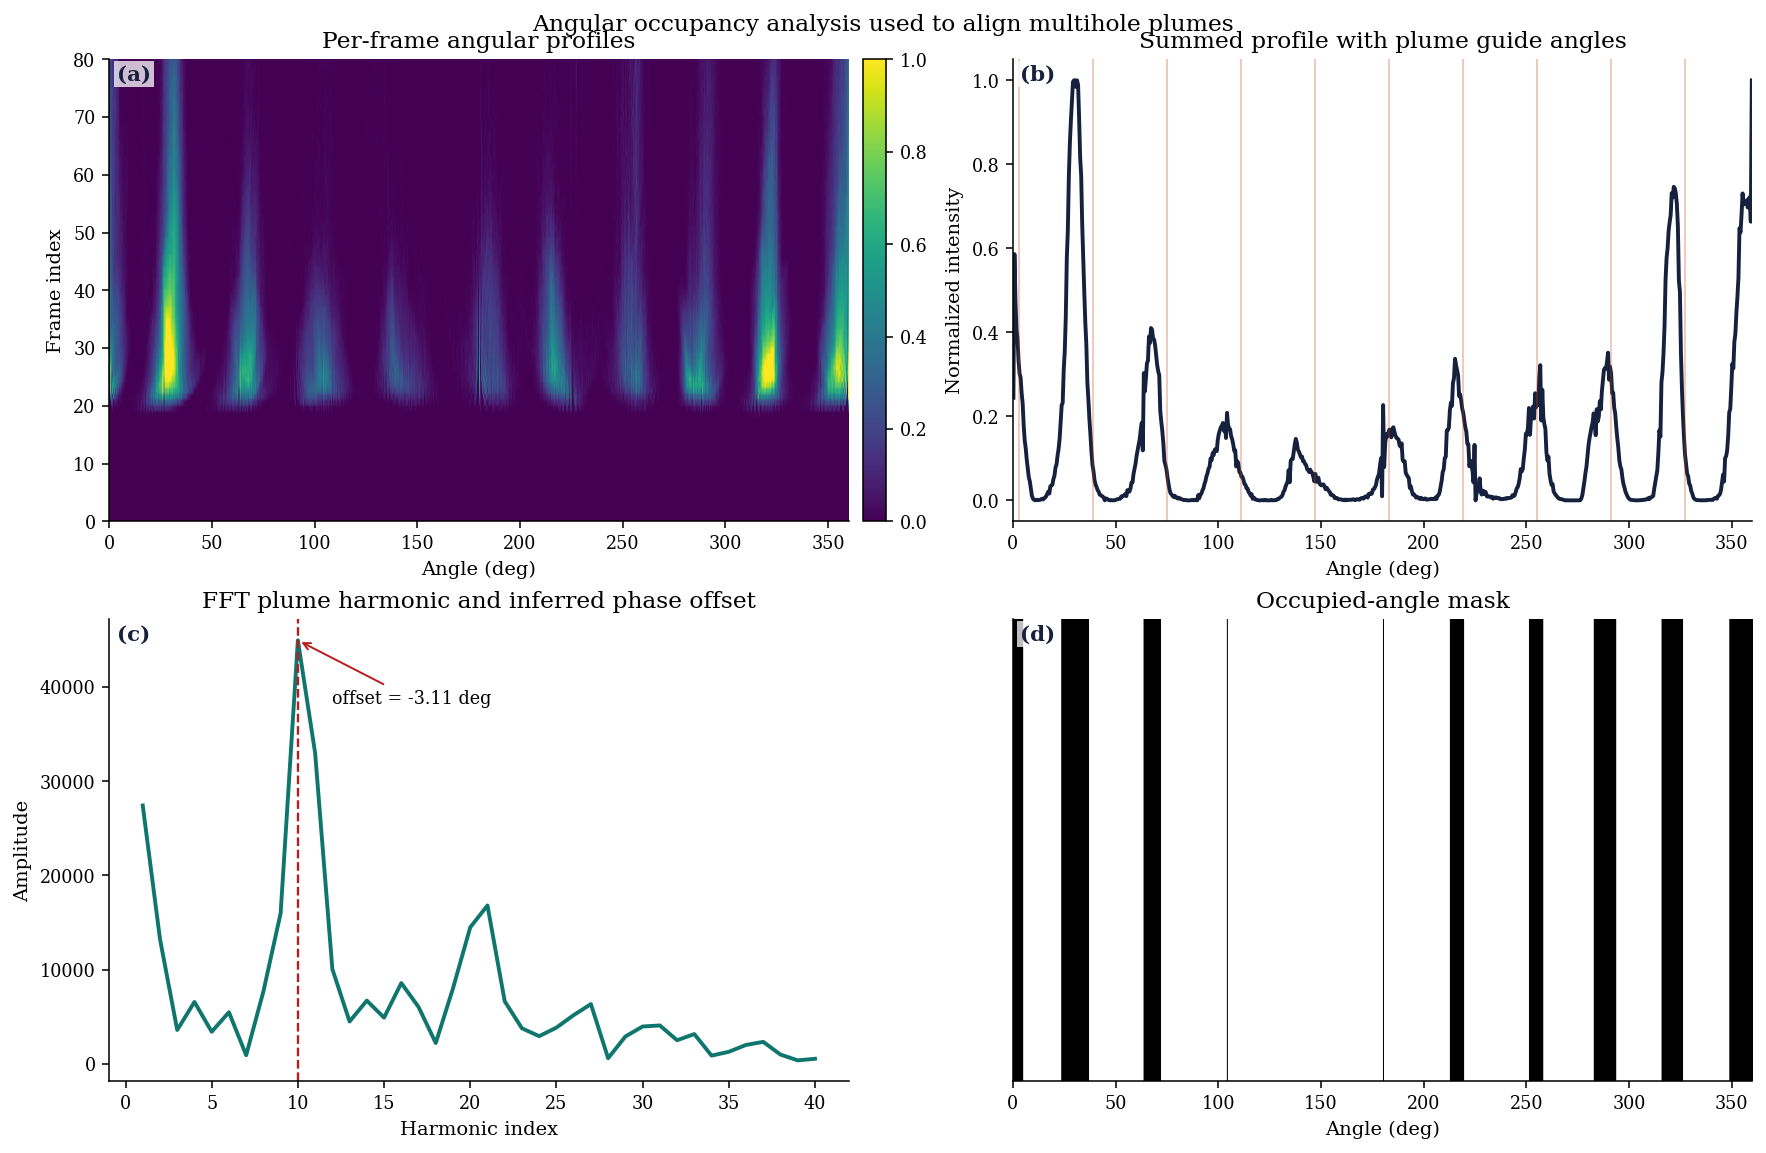

In [122]:
fig, axs = plt.subplots(2, 2, figsize=(12.5, 8.0), constrained_layout=True)
im = axs[0, 0].imshow(robust_scale_local(fig_angular_data["profiles"], q_min=2.0, q_max=99.8), aspect="auto", origin="lower", cmap="viridis", extent=[0.0, 360.0, 0, fig_angular_data["profiles"].shape[0]])
axs[0, 0].set_title("Per-frame angular profiles")
axs[0, 0].set_xlabel("Angle (deg)")
axs[0, 0].set_ylabel("Frame index")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046, pad=0.02)
axs[0, 1].plot(fig_angular_data["bins"], robust_scale_local(fig_angular_data["summed_profile"]), color=COLORS["ink"], lw=2.0)
for angle in fig_angular_data["plume_angles"]:
    axs[0, 1].axvline(angle % 360.0, color=COLORS["warm"], lw=0.8, alpha=0.35)
axs[0, 1].set_xlim(0.0, 360.0)
axs[0, 1].set_title("Summed profile with plume guide angles")
axs[0, 1].set_xlabel("Angle (deg)")
axs[0, 1].set_ylabel("Normalized intensity")
max_harmonic = min(FIG_ANGULAR_PARAMS["max_harmonic"], len(fig_angular_data["fft_amp"]) - 1)
axs[1, 0].plot(fig_angular_data["harmonics"][1:max_harmonic + 1], fig_angular_data["fft_amp"][1:max_harmonic + 1], color=COLORS["accent"], lw=2.0)
axs[1, 0].axvline(MIE_GEOMETRY["plumes"], color=COLORS["red"], lw=1.2, ls="--")
axs[1, 0].annotate(f"offset = {fig_angular_data['offset']:.2f} deg", xy=(MIE_GEOMETRY["plumes"], fig_angular_data["fft_amp"][MIE_GEOMETRY["plumes"]]), xytext=(MIE_GEOMETRY["plumes"] + 2.0, 0.85 * fig_angular_data["fft_amp"][1:max_harmonic + 1].max()), arrowprops={"arrowstyle": "->", "color": COLORS["red"]}, fontsize=9)
axs[1, 0].set_title("FFT plume harmonic and inferred phase offset")
axs[1, 0].set_xlabel("Harmonic index")
axs[1, 0].set_ylabel("Amplitude")
axs[1, 1].imshow(fig_angular_data["occupancy_mask"][None, :], aspect="auto", cmap="gray_r", extent=[0.0, 360.0, 0.0, 1.0])
axs[1, 1].set_title("Occupied-angle mask")
axs[1, 1].set_xlabel("Angle (deg)")
axs[1, 1].set_yticks([])
fig.suptitle("Angular occupancy analysis used to align multihole plumes", y=1.01)
add_panel_labels(axs, labels=["a", "b", "c", "d"])
plt.show()


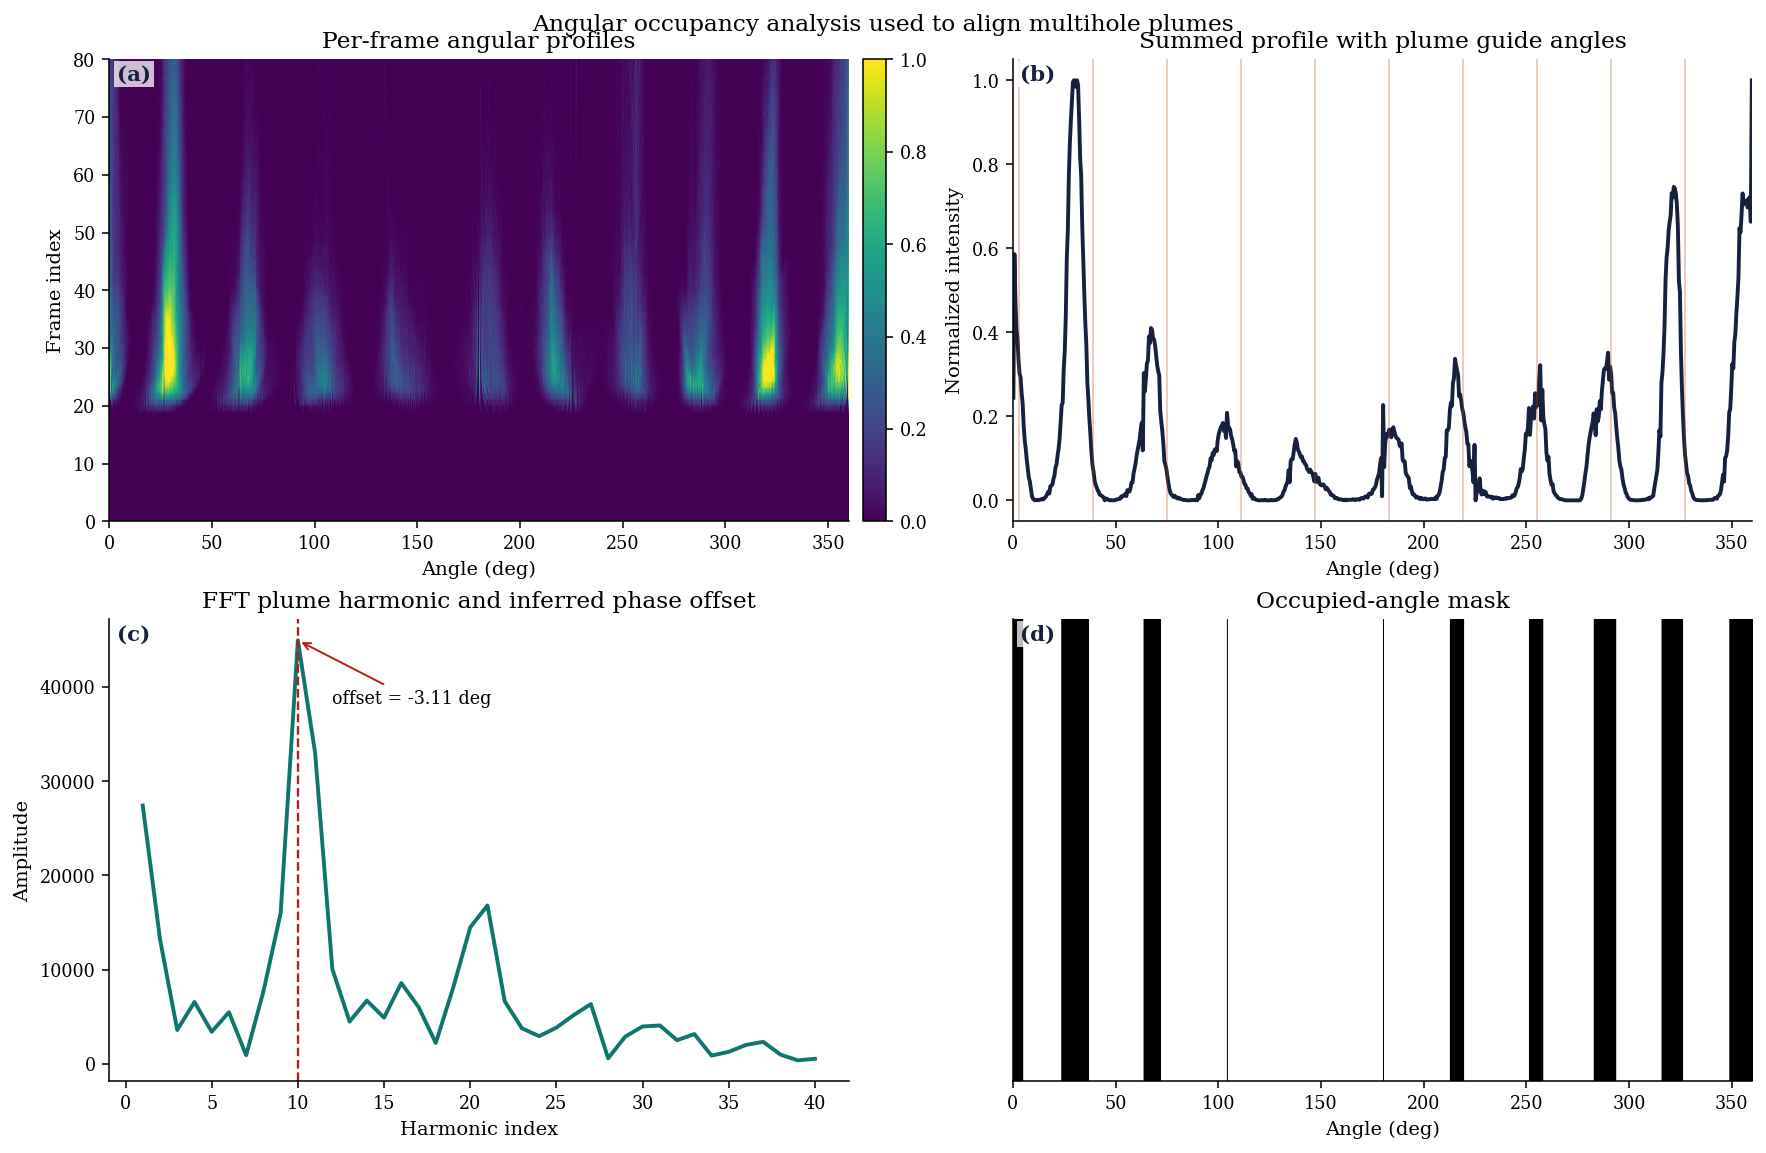

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_angular_occupancy.png


In [123]:
export_figure(fig, FIG_ANGULAR_PARAMS["filename"])
plt.close(fig)


### fig_efficient_rotation_placeholder


In [124]:
FIG_ROTATION_PARAMS = {
    "filename": "fig_efficient_rotation.png",
}
FIG_ROTATION_PARAMS


{'filename': 'fig_efficient_rotation.png'}

In [125]:
fig_rotation_data = {
    "mapx": mie_bundle["mapx"],
    "mapy": mie_bundle["mapy"],
    "rotated_strip": mie_bundle["rotated_strip"],
    "plume_mask": mie_bundle["plume_mask"],
    "reference_angle": mie_bundle["reference_angle"],
}


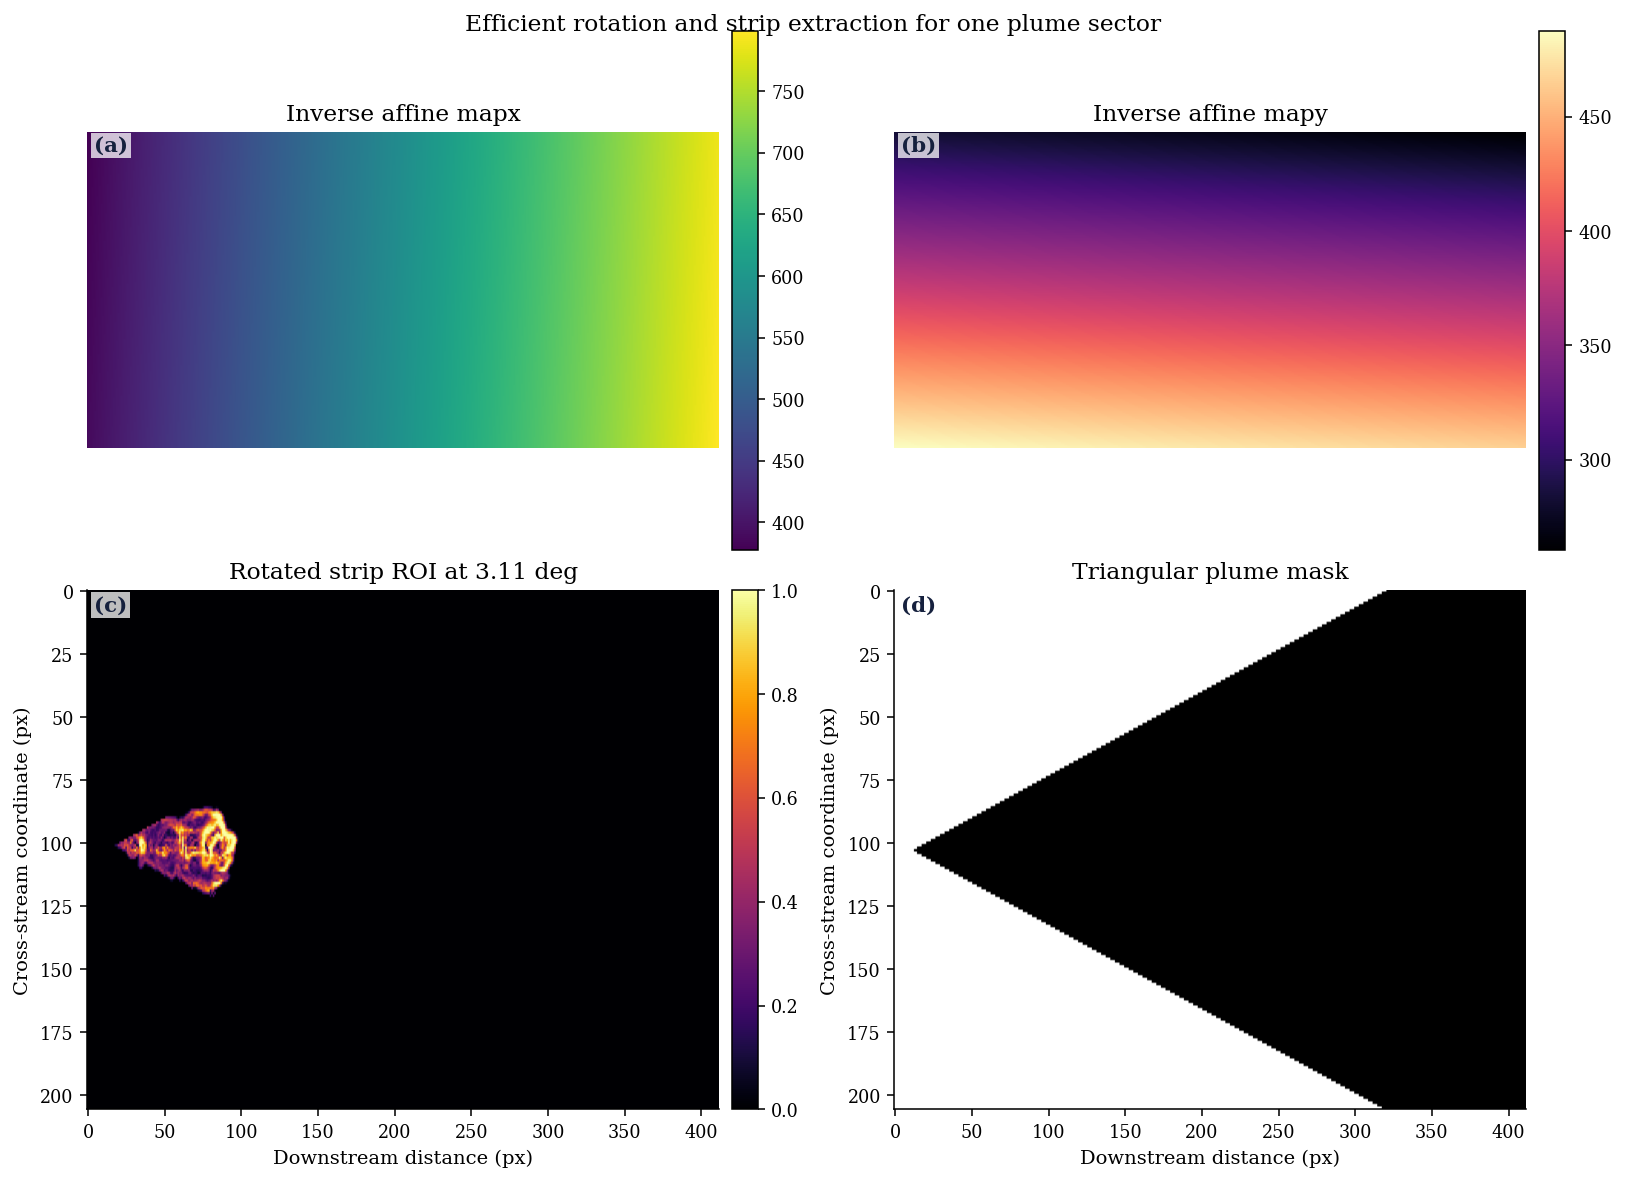

In [126]:
fig, axs = plt.subplots(2, 2, figsize=(11.5, 8.2), constrained_layout=True)
im0 = axs[0, 0].imshow(fig_rotation_data["mapx"], cmap="viridis")
axs[0, 0].set_title("Inverse affine mapx")
axs[0, 0].set_axis_off()
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.02)
im1 = axs[0, 1].imshow(fig_rotation_data["mapy"], cmap="magma")
axs[0, 1].set_title("Inverse affine mapy")
axs[0, 1].set_axis_off()
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.02)
im2 = axs[1, 0].imshow(fig_rotation_data["rotated_strip"], cmap="inferno", aspect="auto")
axs[1, 0].set_title(f"Rotated strip ROI at {fig_rotation_data['reference_angle']:.2f} deg")
axs[1, 0].set_xlabel("Downstream distance (px)")
axs[1, 0].set_ylabel("Cross-stream coordinate (px)")
plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.02)
axs[1, 1].imshow(fig_rotation_data["plume_mask"], cmap="gray_r", aspect="auto")
axs[1, 1].set_title("Triangular plume mask")
axs[1, 1].set_xlabel("Downstream distance (px)")
axs[1, 1].set_ylabel("Cross-stream coordinate (px)")
fig.suptitle("Efficient rotation and strip extraction for one plume sector", y=1.01)
add_panel_labels(axs, labels=["a", "b", "c", "d"])
plt.show()


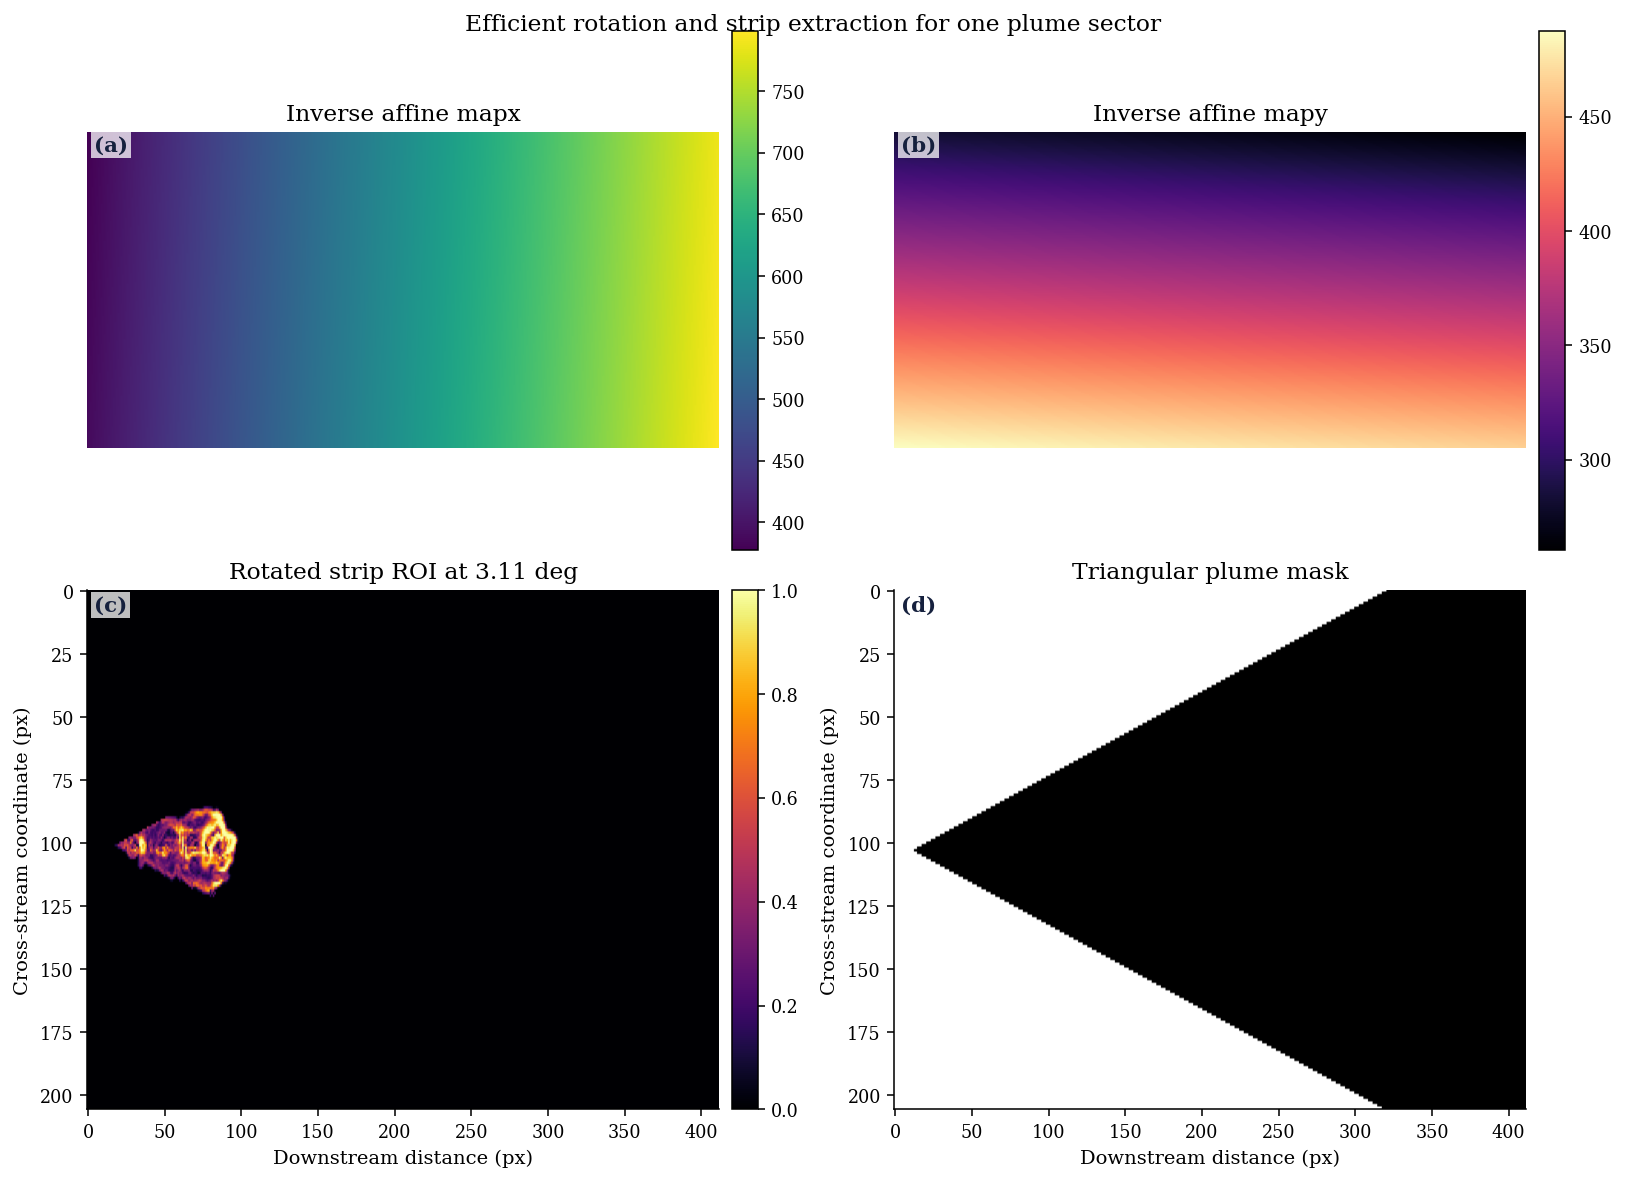

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_efficient_rotation.png


In [127]:
export_figure(fig, FIG_ROTATION_PARAMS["filename"])
plt.close(fig)


### fig_mie_metrics_summary


In [128]:
FIG_METRICS_PARAMS = {
    "filename": "fig_mie_metrics_summary.png",
    "plume_idx": 0,
}
FIG_METRICS_PARAMS


{'filename': 'fig_mie_metrics_summary.png', 'plume_idx': 0}

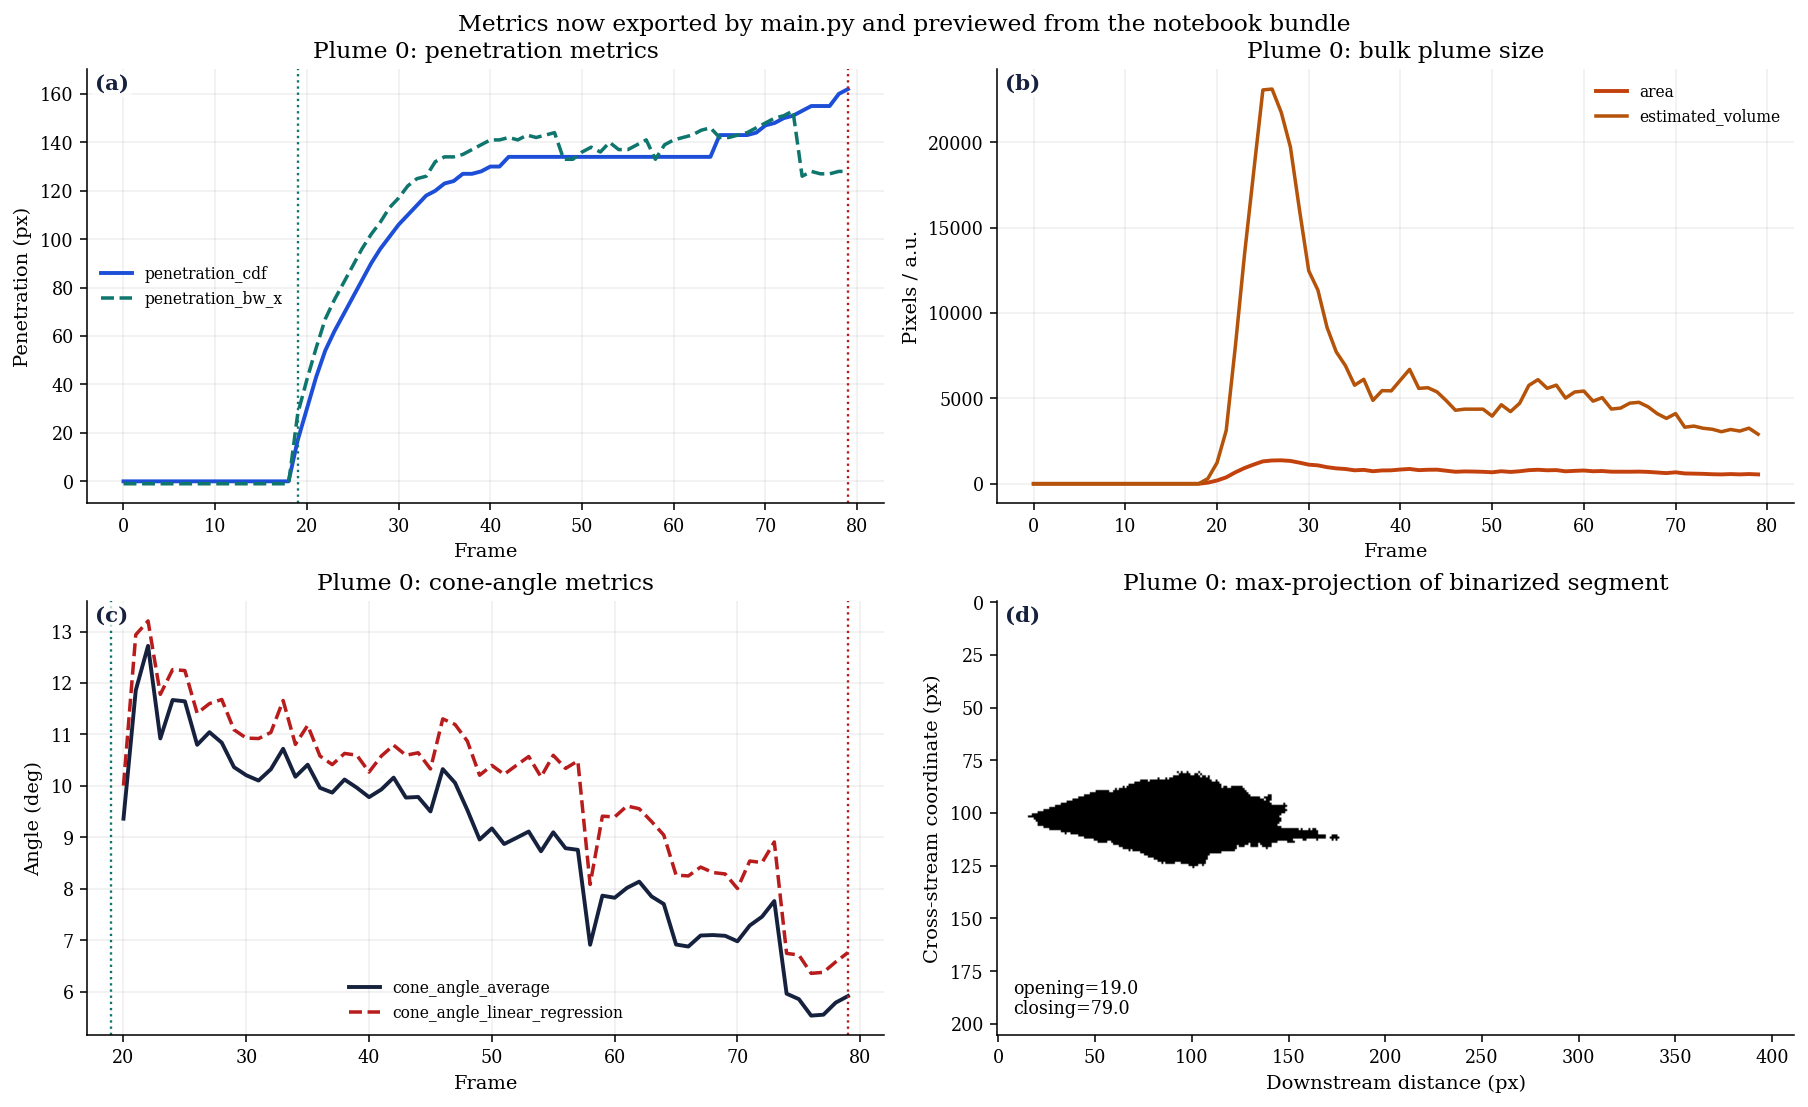

In [129]:
plume_idx = FIG_METRICS_PARAMS["plume_idx"]
metrics_df = mie_bundle["metrics_df"]
metric_data = {
    "penetration_cdf": metrics_df[f"penetration_cdf_plume_{plume_idx}"].to_numpy(),
    "penetration_bw_x": metrics_df[f"penetration_bw_x_plume_{plume_idx}"].to_numpy(),
    "area": metrics_df[f"area_plume_{plume_idx}"].to_numpy(),
    "estimated_volume": metrics_df[f"estimated_volume_plume_{plume_idx}"].to_numpy(),
    "cone_angle_average": metrics_df[f"cone_angle_average_plume_{plume_idx}"].to_numpy(),
    "cone_angle_linear_regression": metrics_df[f"cone_angle_linear_regression_plume_{plume_idx}"].to_numpy(),
    "nozzle_opening": float(metrics_df[f"nozzle_opening_plume_{plume_idx}"].iloc[0]),
    "nozzle_closing": float(metrics_df[f"nozzle_closing_plume_{plume_idx}"].iloc[0]),
}
frame_idx = metrics_df["frame_idx"].to_numpy()

fig, axs = plt.subplots(2, 2, figsize=(12.8, 7.6), constrained_layout=True)
axs[0, 0].plot(frame_idx, metric_data["penetration_cdf"], color=COLORS["blue"], lw=2.0, label="penetration_cdf")
axs[0, 0].plot(frame_idx, metric_data["penetration_bw_x"], color=COLORS["accent"], lw=1.8, ls="--", label="penetration_bw_x")
axs[0, 0].set_title(f"Plume {plume_idx}: penetration metrics")
axs[0, 0].set_xlabel("Frame")
axs[0, 0].set_ylabel("Penetration (px)")
axs[0, 0].legend(frameon=False)
axs[0, 0].grid(True, alpha=0.2)

axs[0, 1].plot(frame_idx, metric_data["area"], color=COLORS["warm"], lw=2.0, label="area")
axs[0, 1].plot(frame_idx, metric_data["estimated_volume"], color=COLORS["gold"], lw=1.8, label="estimated_volume")
axs[0, 1].set_title(f"Plume {plume_idx}: bulk plume size")
axs[0, 1].set_xlabel("Frame")
axs[0, 1].set_ylabel("Pixels / a.u.")
axs[0, 1].legend(frameon=False)
axs[0, 1].grid(True, alpha=0.2)

axs[1, 0].plot(frame_idx, metric_data["cone_angle_average"], color=COLORS["ink"], lw=2.0, label="cone_angle_average")
axs[1, 0].plot(frame_idx, metric_data["cone_angle_linear_regression"], color=COLORS["red"], lw=1.8, ls="--", label="cone_angle_linear_regression")
axs[1, 0].set_title(f"Plume {plume_idx}: cone-angle metrics")
axs[1, 0].set_xlabel("Frame")
axs[1, 0].set_ylabel("Angle (deg)")
axs[1, 0].legend(frameon=False)
axs[1, 0].grid(True, alpha=0.2)

axs[1, 1].imshow(mie_bundle["segments_bw"][plume_idx].max(axis=0), cmap="gray_r", aspect="auto")
axs[1, 1].set_title(f"Plume {plume_idx}: max-projection of binarized segment")
axs[1, 1].set_xlabel("Downstream distance (px)")
axs[1, 1].set_ylabel("Cross-stream coordinate (px)")
for marker, color, label in [
    (metric_data["nozzle_opening"], COLORS["accent"], "opening"),
    (metric_data["nozzle_closing"], COLORS["red"], "closing"),
]:
    if np.isfinite(marker):
        for ax in axs[:, 0]:
            ax.axvline(marker, color=color, ls=":", lw=1.2)
axs[1, 1].text(0.02, 0.04, f"opening={metric_data['nozzle_opening']:.1f}\nclosing={metric_data['nozzle_closing']:.1f}", transform=axs[1, 1].transAxes, ha="left", va="bottom", fontsize=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8})
fig.suptitle("Metrics now exported by main.py and previewed from the notebook bundle", y=1.02)
add_panel_labels(axs, labels=["a", "b", "c", "d"])


In [130]:
metric_data

{'penetration_cdf': array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  17.,  30.,  43.,
         54.,  62.,  69.,  76.,  83.,  90.,  96., 101., 106., 110., 114.,
        118., 120., 123., 124., 127., 127., 128., 130., 130., 134., 134.,
        134., 134., 134., 134., 134., 134., 134., 134., 134., 134., 134.,
        134., 134., 134., 134., 134., 134., 134., 134., 134., 134., 143.,
        143., 143., 143., 144., 147., 148., 150., 151., 153., 155., 155.,
        155., 160., 162.]),
 'penetration_bw_x': array([ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
         -1,  -1,  -1,  -1,  -1,  -1,  28,  42,  55,  67,  75,  82,  89,
         96, 102, 107, 113, 117, 122, 125, 126, 132, 134, 134, 135, 137,
        139, 141, 141, 142, 141, 143, 142, 143, 144, 133, 133, 136, 138,
        136, 140, 137, 137, 139, 141, 133, 139, 141, 142, 143, 145, 146,
        142, 142, 143, 144, 146, 148, 150, 151, 15

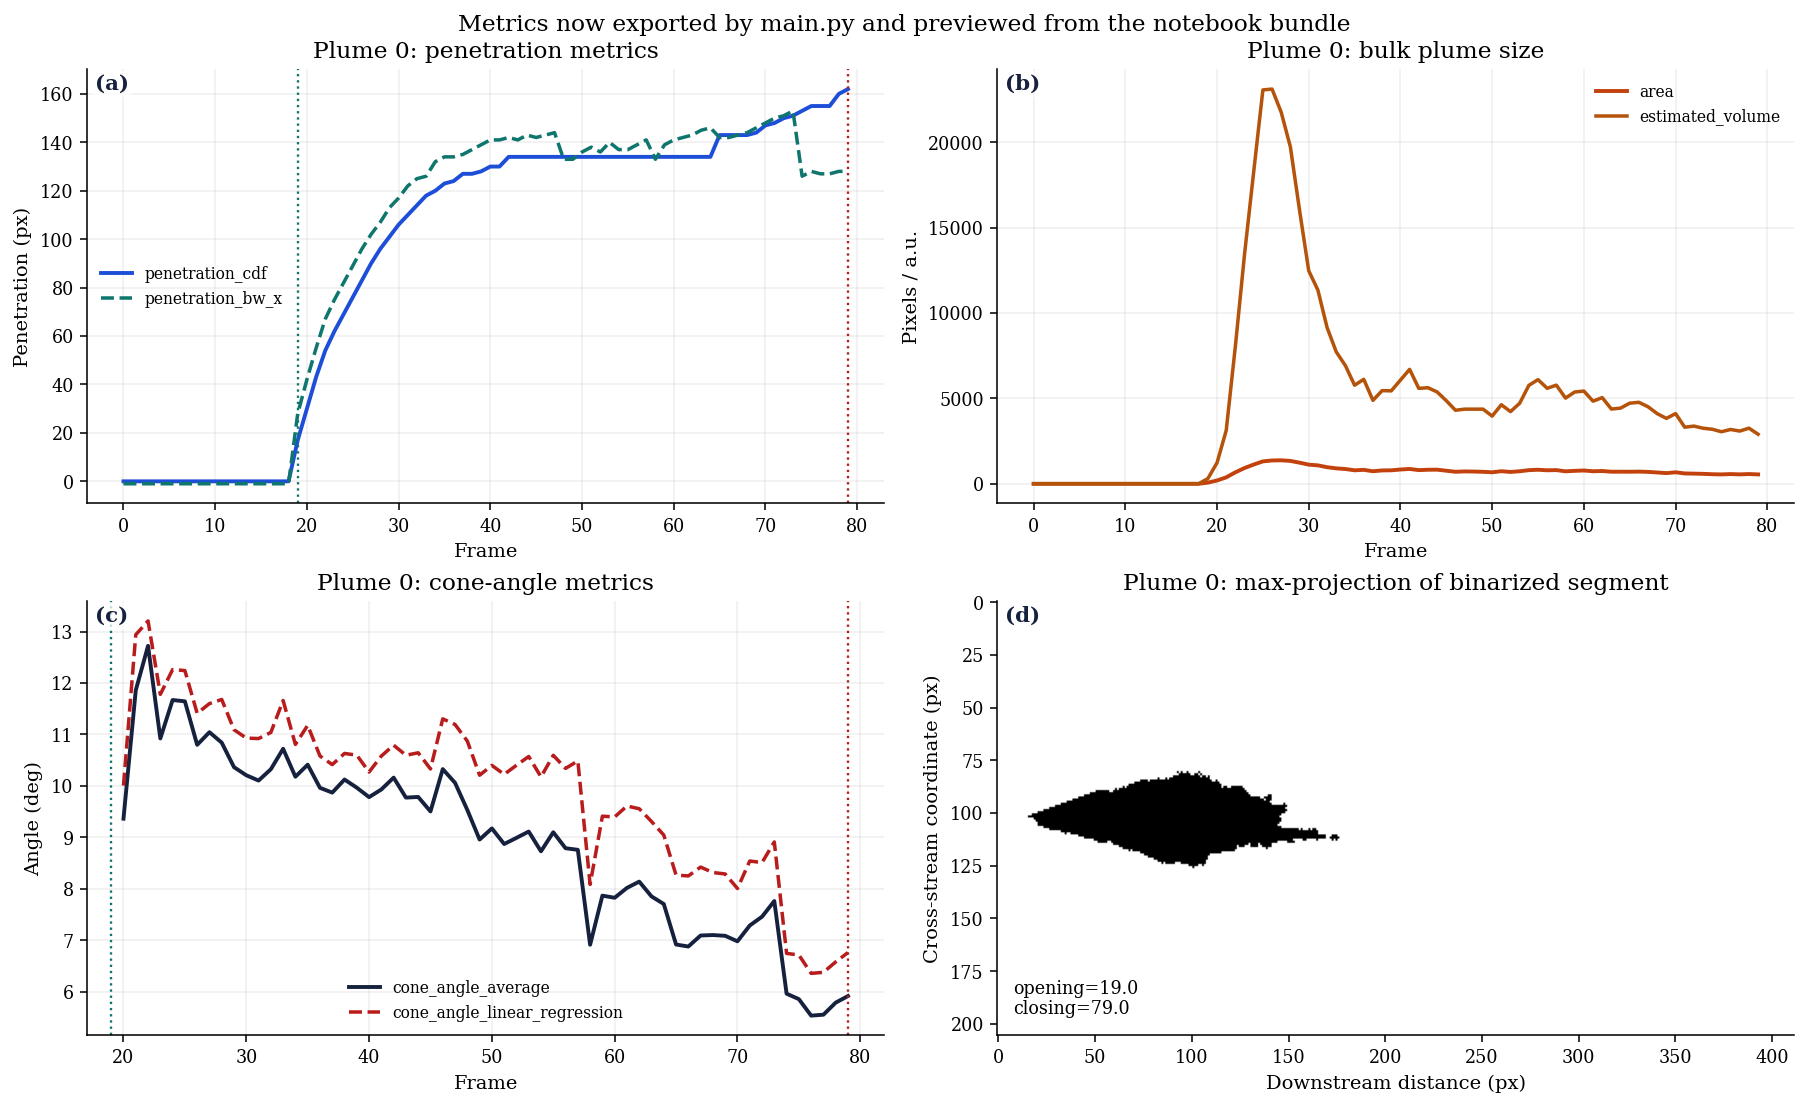

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_metrics_summary.png


In [131]:
export_figure(fig, FIG_METRICS_PARAMS["filename"])
plt.close(fig)


### debug_video_exports_and_playback

Save processed videos and rotated plume segments to AVI. Playback is optional and controlled by flags.


In [ ]:
VIDEO_DEBUG_PARAMS = {
    "prefix": "thesis_publication_figures",
    "save_videos": False,
    "play_processed": True,
    "play_segments": True,
    "gain": 1.0,
    "intv": 17,
}

if VIDEO_DEBUG_PARAMS["save_videos"]:
    save_dir = save_bundle_videos(
        mie_bundle,
        prefix=VIDEO_DEBUG_PARAMS["prefix"],
        fps=mie_bundle["fps"],
    )
    print(f"Saved AVI outputs to {save_dir}")

if VIDEO_DEBUG_PARAMS["play_processed"] or VIDEO_DEBUG_PARAMS["play_segments"]:
    play_bundle_videos(
        mie_bundle,
        play_processed=VIDEO_DEBUG_PARAMS["play_processed"],
        play_segments=VIDEO_DEBUG_PARAMS["play_segments"],
        gain=VIDEO_DEBUG_PARAMS["gain"],
        intv=VIDEO_DEBUG_PARAMS["intv"],
    )


: 

## 04 Stage-1 MLP Figures


### fig_round1_median_selection_placeholder


In [133]:
FIG_ROUND1_SELECTION_PARAMS = {
    "filename": "fig_round1_median_selection.png",
    "comparison_time_s": 5e-3,
    "n_conditions": 3,
    "samples_per_condition": 7,
}
FIG_ROUND1_SELECTION_PARAMS


{'filename': 'fig_round1_median_selection.png',
 'comparison_time_s': 0.005,
 'n_conditions': 3,
 'samples_per_condition': 7}

In [134]:
def spray_penetration_model_sigmoid(params, t):
    log_k_sqrt, log_k_quarter, log_t0, log_s = params
    k_sqrt = np.exp(log_k_sqrt)
    k_quarter = np.exp(log_k_quarter)
    t0 = np.exp(log_t0)
    s = np.exp(log_s)
    t = np.clip(np.asarray(t, dtype=float), 1e-9, None)
    sqrt_segment = k_sqrt * np.sqrt(t)
    quarter_segment = k_quarter * np.power(t, 0.25)
    blend = 1.0 / (1.0 + np.exp(-(t - t0) / s))
    return (1.0 - blend) * sqrt_segment + blend * quarter_segment


def select_row_closest_to_median_penetration(rows, compare_time_s):
    compare_vals = np.array([spray_penetration_model_sigmoid(row["params"], compare_time_s) for row in rows], dtype=float)
    median_val = float(np.nanmedian(compare_vals))
    selected_idx = int(np.nanargmin(np.abs(compare_vals - median_val)))
    return selected_idx, median_val, compare_vals


time_grid = np.linspace(0.0, 8e-3, 240)
condition_names = ["A: low chamber p", "B: medium chamber p", "C: high chamber p"]
condition_rows = []
base_param_sets = [
    np.log([95.0, 62.0, 2.5e-3, 0.65e-3]),
    np.log([118.0, 74.0, 2.1e-3, 0.58e-3]),
    np.log([136.0, 87.0, 1.8e-3, 0.52e-3]),
]

for condition_name, base_params in zip(condition_names, base_param_sets):
    rows = []
    for sample_idx in range(FIG_ROUND1_SELECTION_PARAMS["samples_per_condition"]):
        perturb = np.array([0.06 * (sample_idx - 3), -0.03 * math.cos(sample_idx), 0.05 * math.sin(sample_idx / 2.0), -0.04 * math.cos(sample_idx / 3.0)])
        params = base_params + perturb
        rows.append({"condition": condition_name, "sample_idx": sample_idx, "params": params, "curve": spray_penetration_model_sigmoid(params, time_grid)})
    selected_idx, median_val, compare_vals = select_row_closest_to_median_penetration(rows, FIG_ROUND1_SELECTION_PARAMS["comparison_time_s"])
    for row, compare_val in zip(rows, compare_vals):
        row["compare_val"] = float(compare_val)
    condition_rows.append({"condition": condition_name, "rows": rows, "selected_idx": selected_idx, "median_val": median_val})


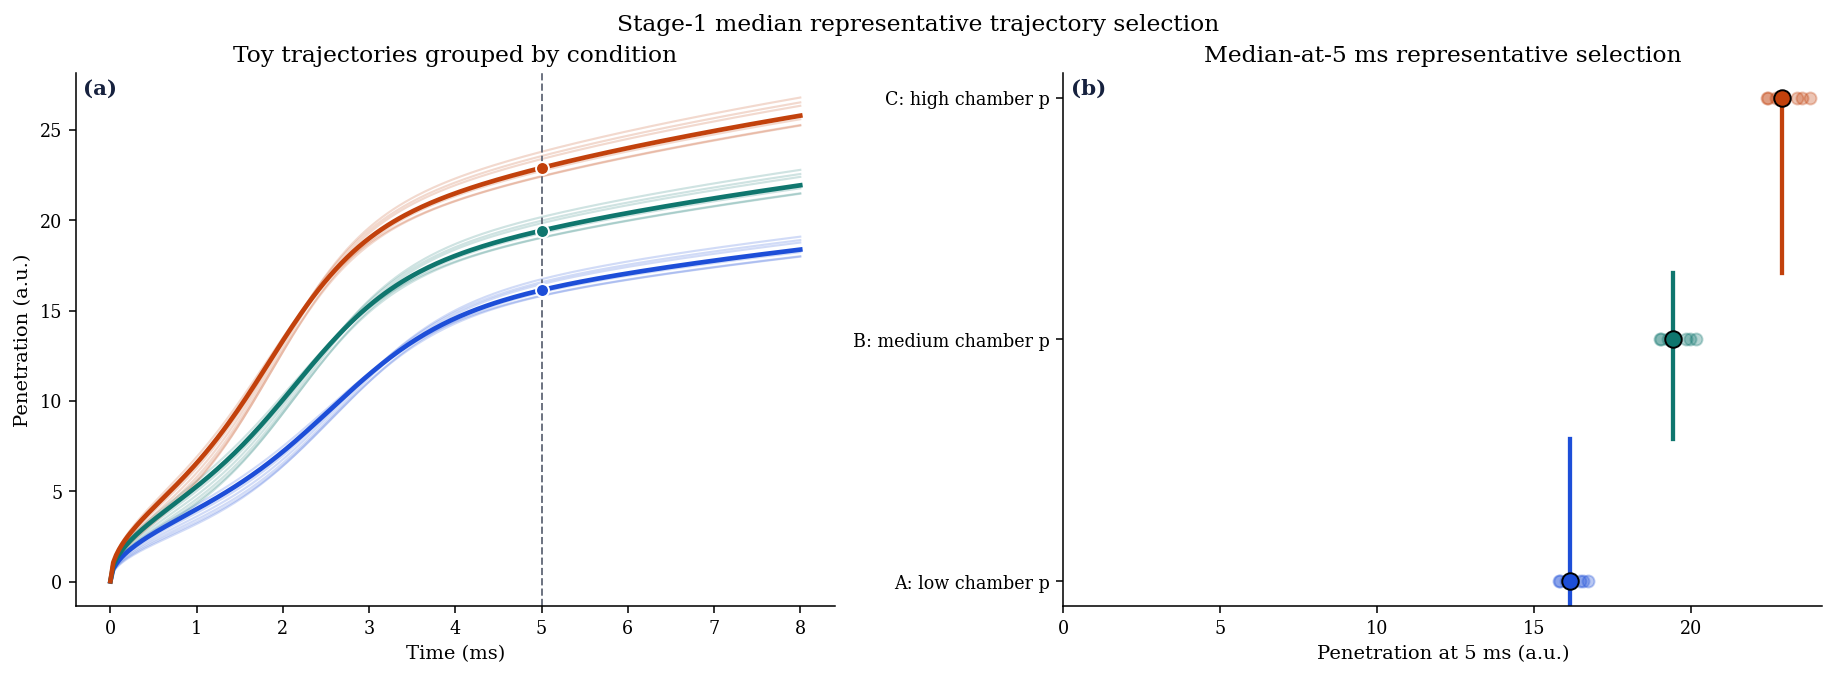

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(13.0, 4.5), constrained_layout=True)
condition_palette = [COLORS["blue"], COLORS["accent"], COLORS["warm"]]
compare_time_ms = 1e3 * FIG_ROUND1_SELECTION_PARAMS["comparison_time_s"]
for cond_data, color in zip(condition_rows, condition_palette):
    for row in cond_data["rows"]:
        alpha = 0.20
        lw = 1.1
        zorder = 1
        if row["sample_idx"] == cond_data["selected_idx"]:
            alpha = 1.0
            lw = 2.4
            zorder = 4
        axs[0].plot(1e3 * time_grid, row["curve"], color=color, alpha=alpha, lw=lw, zorder=zorder)
    selected_row = cond_data["rows"][cond_data["selected_idx"]]
    axs[0].scatter(compare_time_ms, selected_row["compare_val"], color=color, edgecolor="white", s=44, zorder=5)
axs[0].axvline(compare_time_ms, color=COLORS["gray"], ls="--", lw=1.0)
axs[0].set_title("Toy trajectories grouped by condition")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Penetration (a.u.)")
for cond_y, (cond_data, color) in enumerate(zip(condition_rows, condition_palette), start=1):
    vals = [row["compare_val"] for row in cond_data["rows"]]
    axs[1].scatter(vals, np.full(len(vals), cond_y), color=color, alpha=0.30, s=38)
    axs[1].axvline(cond_data["median_val"], ymin=(cond_y - 1) / 3.2, ymax=cond_y / 3.2, color=color, lw=2.2)
    selected_val = cond_data["rows"][cond_data["selected_idx"]]["compare_val"]
    axs[1].scatter(selected_val, cond_y, color=color, edgecolor="black", s=72, zorder=5)
axs[1].set_yticks([1, 2, 3], labels=condition_names)
axs[1].set_title("Median-at-5 ms representative selection")
axs[1].set_xlabel("Penetration at 5 ms (a.u.)")
axs[1].set_xlim(left=0)
fig.suptitle("Stage-1 median representative trajectory selection", y=1.04)
add_panel_labels(axs, labels=["a", "b"])
plt.show()


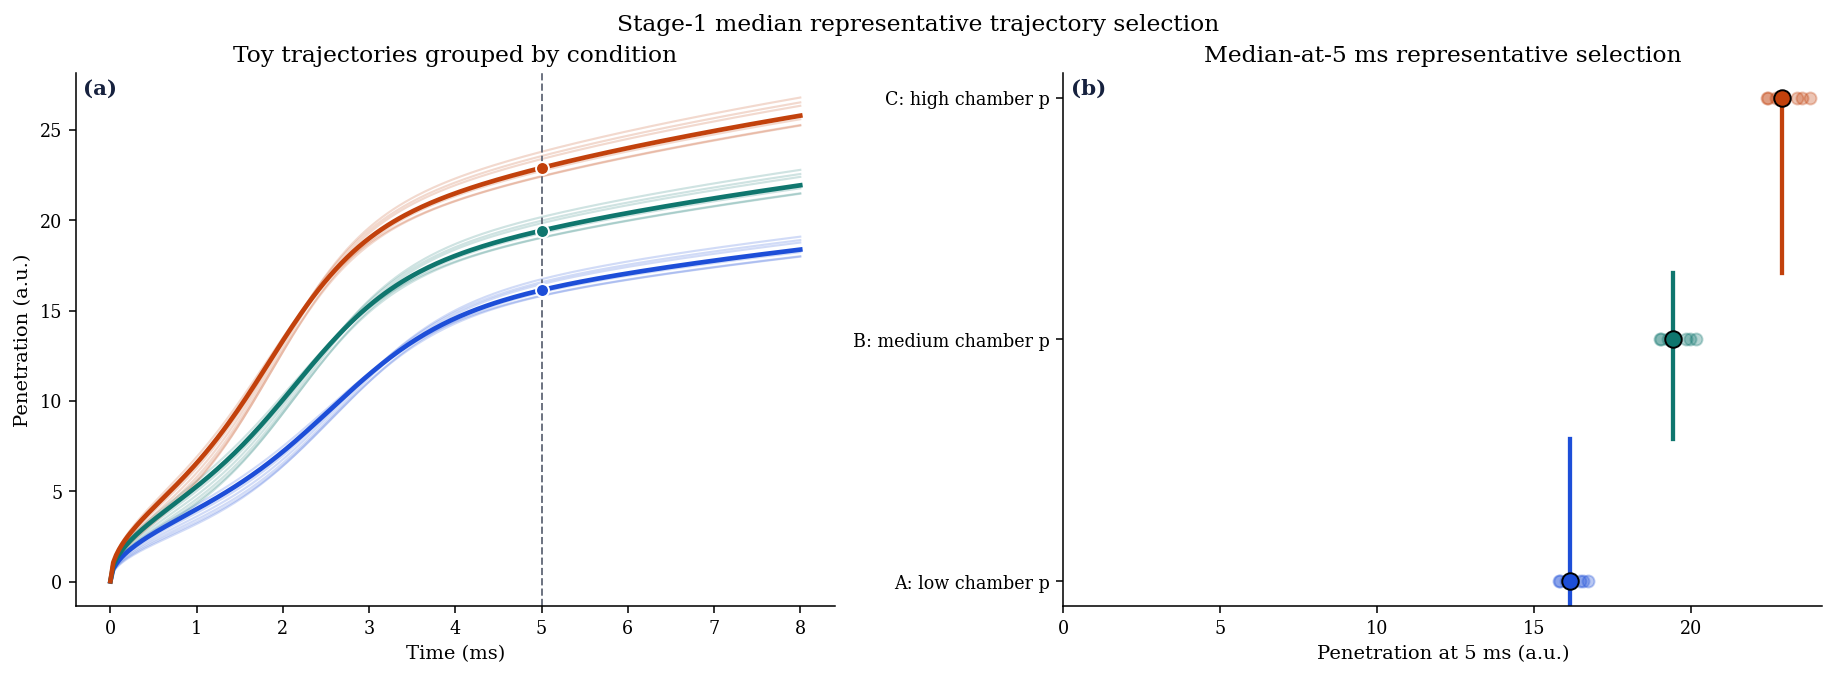

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_round1_median_selection.png


In [136]:
export_figure(fig, FIG_ROUND1_SELECTION_PARAMS["filename"])
plt.close(fig)


### fig_round1_loss_placeholder


In [137]:
FIG_ROUND1_LOSS_PARAMS = {
    "filename": "fig_round1_loss.png",
    "csv_path": ROUND1_LOSS_CSV,
}
FIG_ROUND1_LOSS_PARAMS


{'filename': 'fig_round1_loss.png',
 'csv_path': WindowsPath('C:/Users/Jiang/Documents/Mie_Postprocessing_Py/MLP/stage1_median_penetration_20260306_172838/epoch_loss.csv')}

In [138]:
df_loss = pd.read_csv(FIG_ROUND1_LOSS_PARAMS["csv_path"])
df_epoch = df_loss.copy()
df_epoch.head()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Jiang\\Documents\\Mie_Postprocessing_Py\\MLP\\stage1_median_penetration_20260306_172838\\epoch_loss.csv'

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
for split, linestyle in [("train", "-"), ("val", "--")]:
    sel = df_epoch[df_epoch["split"] == split]
    axs[0].plot(sel["epoch"], sel["loss"], color=COLORS["ink"], lw=2.0, ls=linestyle, label=f"{split} total")
    axs[0].plot(sel["epoch"], sel["mse"], color=COLORS["accent"], lw=1.8, ls=linestyle, label=f"{split} mse")
    axs[1].plot(sel["epoch"], sel["d1_penalty"], color=COLORS["warm"], lw=1.8, ls=linestyle, label=f"{split} d1")
    axs[1].plot(sel["epoch"], sel["d2_penalty"], color=COLORS["red"], lw=1.8, ls=linestyle, label=f"{split} d2")
axs[0].set_title("Total loss and MSE")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend(frameon=False, ncols=2)
axs[1].set_title("Derivative regularization penalties")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Penalty")
axs[1].legend(frameon=False, ncols=2)
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, alpha=0.20)
fig.suptitle("Stage-1 training history from epoch_loss.csv", y=1.03)
add_panel_labels(axs, labels=["a", "b"])
plt.show()


In [ ]:
export_figure(fig, FIG_ROUND1_LOSS_PARAMS["filename"])
plt.close(fig)


## 05 Manual and Deferred Figures

Manual GUI figures:

- `images/fig_gui_main_window.png`
- `images/fig_gui_point_selection.png`
- `images/fig_gui_calibration_overlay.png`

Deferred deep-learning figures for later rounds:

- `images/fig_round2_uncertainty.png`
- `images/fig_round3_refinement.png`

Current notebook behavior:

- uses the `T13/config.json` geometry directly for all Mie overlays
- prefers one real cine sample when the kernel can load it
- falls back to a geometry-matched synthetic video when cine loading is unavailable
